# Imports

In [127]:
# Imports and setup
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GridSearchCV

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mutual_info_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler


from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

import xgboost as xgb
from xgboost import XGBRegressor

from sklearn.ensemble import StackingRegressor

from sklearn.feature_selection import mutual_info_regression 
from sklearn.feature_selection import f_regression

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder

from sklearn import metrics


import category_encoders as ce

from datetime import datetime
import time
from IPython.display import display, HTML

from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy import stats

import os
import itables
from itables import show
import warnings
from typing import Protocol
from sklearn.exceptions import ConvergenceWarning


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Constants

In [2]:
# Some useful constants
TARGET_COL = "SalePrice"
LOGP_TARGET_COL = f"{TARGET_COL}_log1p"
RANDOM_STATE = 0
TEST_PORCENT = 0.2  # Proportion of the dataset to include in the test split
MAX_OHE_CARDINALITY = 18  # Maximum unique values for one-hot encoding

g_df_scores = pd.DataFrame() #  DataFrame to store scores
g_run_id = 0  # Global run id to use in scores


# Columns

In [3]:
# Ordinal Columns
# OverallCond and OverallQuall are ordinal but no process is necessary

ORD_COLS_VALUES = { 
    "LandSlope": {"Gtl": 1, "Mod": 2, "Sev": 3},
    "ExterQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "ExterCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "BsmtQual": {"Ex": 10, "Gd": 9, "TA": 8, "Fa": 7, "Po": 3, "NA": 0},
    "BsmtCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "BsmtExposure": {"Gd": 5, "Av": 4, "Mn": 3, "No": 2, "NA": 0},
    "BsmtFinType1": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, 'NA':0},
    'BsmtFinType2': {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'NA':0},
    'HeatingQC':{'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1},
    "KitchenQual": {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1},
    'FireplaceQu':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'GarageQual':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'GarageCond':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'PoolQC' : {'Ex' :10 , 'Gd' :9 , 'TA' :8 , 'Fa' :7 , 'Po' :3 , 'NA' :0},
    "Fence": {"GdPrv": 4, "MnPrv": 3, "GdWo": 2, "MnWw": 1, "NA": 0},
}

ORD_COLS = list(ORD_COLS_VALUES.keys())

## Class categories
CLASS_COLS_VALUES = {
    "MSSubClass": [20, 30, 40, 45, 50, 60, 70, 75, 80, 85, 90, 120, 150, 160, 180, 190],
    "MSZoning": ["A", "C", "FV", "I", "RH", "RL", "RP", "RM"],
    "Street": ["Grvl", "Pave"],
    "Alley": ["Grvl", "Pave", "NA"],
    "LotShape": ["Reg", "IR1", "IR2", "IR3"],
    "LandContour": ["Lvl", "Bnk", "HLS", "Low"],
    "Utilities": ["AllPub", "NoSewr", "NoSeWa", "ELO"],
    "LotConfig": ["Inside", "Corner", "CulDSac", "FR2", "FR3"],
    "LandSlope": ["Gtl", "Mod", "Sev"],
    "Condition1": ["Artery", "Feedr", "Norm", "RRNn", "RRAn", "PosN", "PosA", "RRNe", "RRAe"],
    "Condition2": ["Artery", "Feedr", "Norm", "RRNn", "RRAn", "PosN", "PosA", "RRNe", "RRAe"],
    "BldgType": ["1Fam", "2FmCon", "Duplx", "TwnhsE", "TwnhsI"],
    "HouseStyle": ["1Story", "1.5Fin", "1.5Unf", "2Story", "2.5Fin", "2.5Unf", "SFoyer", "SLvl"],
    "RoofStyle": ["Flat", "Gable", "Gambrel", "Hip", "Mansard", "Shed"],
    "RoofMatl": ["ClyTile", "CompShg", "Membran", "Metal", "Roll", "Tar&Grv", "WdShake", "WdShngl"],
    "Exterior1st": ["AsbShng", "AsphShn", "BrkComm", "BrkFace", "CBlock", "CemntBd", "HdBoard", "ImStucc", "MetalSd", "Other", "Plywood", "PreCast", "Stone", "Stucco", "VinylSd", "Wd Sdng", "WdShing"],
    "Exterior2nd": ["AsbShng", "AsphShn", "BrkComm", "BrkFace", "CBlock", "CemntBd", "HdBoard", "ImStucc", "MetalSd", "Other", "Plywood", "PreCast", "Stone", "Stucco", "VinylSd", "Wd Sdng", "WdShing"],
    "MasVnrType": ["BrkCmn", "BrkFace", "CBlock", "None", "Stone"],
    "Foundation": ["BrkTil", "CBlock", "PConc", "Slab", "Stone", "Wood"],
    "Heating": ["Floor", "GasA", "GasW", "Grav", "OthW", "Wall"],
    "Electrical": ["SBrkr", "FuseA", "FuseF", "FuseP", "Mix"],
    "Functional": ["Typ", "Min1", "Min2", "Mod", "Maj1", "Maj2", "Sev", "Sal"],
    "GarageType": ["2Types", "Attchd", "Basment", "BuiltIn", "CarPort", "Detchd", "NA"],
    "GarageFinish": ["Fin", "RFn", "Unf", "NA"],
    "PavedDrive": ["Y", "P", "N"],
    "MiscFeature": ["Elev", "Gar2", "Othr", "Shed", "TenC", "NA"],
    "SaleType": ["WD", "CWD", "VWD", "New", "COD", "Con", "ConLw", "ConLI", "ConLD", "Oth"],
    "SaleCondition": ["Normal", "Abnorml", "AdjLand", "Alloca", "Family", "Partial"], 
    "CentralAir": ["Y", "N"],
}

In [4]:
list(ORD_COLS)

['LandSlope',
 'ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'HeatingQC',
 'KitchenQual',
 'FireplaceQu',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence']

# Functions

## Print Info Functions

In [5]:
def print_null_count(df, col_name):
    """
    Print the number of null values in a specific column of a DataFrame.
    
    Parameters:
    df (pd.DataFrame): The DataFrame to check.
    col_name (str): The name of the column to check for null values.
    """
    print(f"Column '{col_name}' has {df[col_name].isnull().sum()} null values.")

def println(ch="-", n=30):
  print(ch * n)

def printspace():
  println(ch=" ")

def show_global_scores():
    global g_df_scores
    display(g_df_scores)


## Plot functions

In [6]:
def compute_fig_matrix_size(features):
  plot_count = len(features)
  if plot_count == 0:
    return
    
  # Show 'num_cols' plots per row
  col_count = min(plot_count, 3)
  row_count = plot_count // col_count
  row_count += 0 if (plot_count % col_count) == 0 else 1
  
  return row_count, col_count

### Show Histograms

In [7]:

def show_histogram(data, features):
  build_bar_plot(data, features, ptype="histogram")
  
def show_bar_plot(data, features):
  build_bar_plot(data, features, ptype="bar")

def build_bar_plot(data, features, ptype="bar"):
    if type(features) is not list:
        features = [features]

    row_count, num_cols = compute_fig_matrix_size(features)
    # Create subplots
    fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(10, 10), squeeze=False)
    fig.tight_layout(pad=2.0)

    curr_row = 0
    curr_col = 0
    for feat_idx, feat_name in enumerate(features):
        curr_row = feat_idx // num_cols
        ax = axes[curr_row, curr_col]
        if ptype == "histogram":
          ax.hist(data[feat_name], bins=30, color="skyblue", alpha=0.7, edgecolor="black", density=True)
        elif ptype == "bar":
          categories = data[feat_name].unique()
          counts =  data[feat_name].value_counts()
          #print("Categories for", feat_name, ":", categories)
          #print("counts for", feat_name, ":", counts)
          ax.bar(categories, counts) 
        ax.set_title("")
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Frequency") 
        if curr_col == num_cols - 1:
            curr_col = 0
        else:
            curr_col += 1

    # Show plot
    plt.show()

### Show Distribution

In [8]:
def show_distribution(data, features):
    if type(features) is not list:
        features = [features]
    
    plot_count = len(features)
    if plot_count == 0:
        return

    
    # Show 'num_cols' plots per row
    num_cols = min(plot_count, 3)
    row_count = plot_count // num_cols
    row_count += 0 if (plot_count % num_cols) == 0 else 1
    # Create subplots
    fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(10, 5), squeeze=False)
    fig.tight_layout(pad=2.0)

    curr_row = 0
    curr_col = 0
    for feat_idx, feat_name in enumerate(features):
        kde = gaussian_kde(data[feat_name])
        mu, sigma = np.mean(data[feat_name]), np.std(data[feat_name])
        x_vals = np.linspace(data[feat_name].min(), data[feat_name].max(), 200)
        
        curr_row = feat_idx // num_cols
        ax = axes[curr_row, curr_col]
        ax.plot(x_vals, kde(x_vals), color="red", lw=2)
        ax.plot(x_vals, norm.pdf(x_vals, mu, sigma), color="yellow", lw=2)
        ax.hist(data[feat_name], bins=30, color="skyblue", alpha=0.7, edgecolor="black", density=True)
        #ax.set_title(f"Distribution for {feat_name}")
        ax.set_title("")
        ax.set_xlabel(feat_name)
        ax.set_ylabel("Frequency") 
        if curr_col == num_cols - 1:
            curr_col = 0
        else:
            curr_col += 1

    # Show plot
    plt.show()

### Show Q-Q Plot

In [9]:
def show_qq_plot(df, features):
  if type(features) is not list:
    features = [features]
    
  plot_count = len(features)
  if plot_count == 0:
    return

  # Show 'num_cols' plots per row
  num_cols = min(plot_count, 3)
  row_count = plot_count // num_cols
  row_count += (0 if plot_count % num_cols == 0 else 1)
  print("Row count", row_count)
  # Create subplots
  curr_row = 0
  curr_col = 0
  fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(7, 5), squeeze=False)
  fig.tight_layout(pad=2.0)
  for i, f in enumerate(features):
    curr_row = i // num_cols
    ax = axes[curr_row, curr_col]
    stats.probplot(df[f], dist="norm", plot=ax)
    ax.set_ylabel(f)
    ax.set_xlabel("q") 
    ax.set_title(f"Q-Q Plot for {f}")
    if curr_col == num_cols - 1:
      curr_col = 0
    else:
      curr_col += 1
  plt.show()

### Scores

In [10]:
def clear_global_scores():
  global g_df_scores
  global g_run_id
  g_run_id = 0
  g_df_scores = pd.DataFrame()

def mark_failed_score(run_id):
  g_df_scores.loc[g_df_scores["run_id"] == run_id, "failed"] = True

SHOW_ALL="all"
SHOW_LAST_10="last_10"
SHOW_LABEL="label"
SHOW_BEST_5="best_5"
def plot_scores(show_test=False, show=SHOW_LAST_10, label=""):

  df = g_df_scores.copy()

  if show == SHOW_LAST_10:
    df = df.tail(10)
  elif show == SHOW_LABEL:
    df = df[df["run_label"] == label]
  elif show == SHOW_BEST_5:
    df = df.sort_values(by="CV_MEAN").tail(5)
    
  # Combine model + run label for easier plotting
  df["model_run"] = df["model"].astype(str) + "\n(" + df["run_label"].astype(str) + ")"

  # Assign a unique color per model
  unique_models = df["model"].unique()
  colors = plt.cm.tab10(range(len(unique_models)))  # 10 distinct colors
  color_map = dict(zip(unique_models, colors))

  # Map the colors to each row
  df["color"] = df["model"].map(color_map)

  # Set figure and subplots
  splot_count = 2
  if show_test:
    splot_count = 3

  fig, axes = plt.subplots(splot_count, 1, figsize=(14, 5))

  axnum = 0
  # --- Bar chart for Train RMSE ---
  bars = axes[axnum].bar(df["model_run"], df["TRN_RMSE"], color=df["color"])
  axes[axnum].set_title("Train set (RMSE)")
  axes[axnum].set_ylabel("RMSE")
  axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)   

  if show_test:
    axnum += 1
    # --- Bar chart for Test RMSE ---
    bars = axes[axnum].bar(df["model_run"], df["TST_RMSE"], color=df["color"])
    axes[axnum].set_title("Test set (RMSE)")
    axes[axnum].set_ylabel("RMSE")
    axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)

  # --- Bar chart for CV_MEAN ---
  axnum += 1
  bars = axes[axnum].bar(df["model_run"], df["CV_MEAN"], color=df["color"])
  axes[axnum].set_title("Cross validation (CV_MEAN)")
  axes[axnum].set_ylabel("CV_MEAN")
  axes[axnum].bar_label(bars, fmt="%.4f", rotation=90, padding=3)

  plt.tight_layout()
  plt.show() 

### Show Scores Stats

In [11]:
def show_run_desc(run_id, model):
    df = g_df_scores[g_df_scores["run_id"] == run_id]
    df = df[df["model"] == model]
    df = df.iloc[0]
    print("RunId:", f"{run_id} ({df["run_label"]}) - model:", df["model"], ("[Failed]" if df["failed"] else ""))
    print("Score:", nfmt(df["CV_MEAN"]), "- TRN_RMSE:", nfmt(df["TRN_RMSE"]))
    print("Description:")
    print(g_df_scores[g_df_scores["run_id"] == run_id]["DESC"]) 

#show_run_desc(103, "Rig")

In [12]:
def show_scores_stats(by_label_list=False, process_time=False, by_model_desc=False, show_test=False, run_id=None):
  global g_df_scores
  curr_validation_tag = "KFolds+cross_val_score"
  df_base = g_df_scores[g_df_scores["failed"] == False].copy()
  # Adding filter to display values after changing cross val split
  df_base = df_base[df_base["validation_tag"] == curr_validation_tag]
  if run_id is None:
      run_id = df_base["run_id"].max()
  df_last = df_base[df_base["run_id"] == run_id]
  println()

  """
   Display last experiment run data
  """
  print("Last Run:", df_last["run_id"].iloc[0], "-", df_last["run_label"].iloc[0])
  println()
  for i, row in df_last.iterrows():
    line = f"Model: {row["model"]} CV_MEAN: {nfmt(row['CV_MEAN'])} ({nfmt(row['CV_STD'])}), TRN_RMSE: {nfmt(row['TRN_RMSE'])}"
    if show_test:
      line+= f" TST_RMSE: {nfmt(row["TST_RMSE"])}"
    print(line)
  print("Description:", df_last["DESC"].iloc[0])

  """
    Display average by Run Label
  """
  if by_label_list:
    df = df_base.groupby("run_label")
    println()
    print("Score Stats")
    println()
    for name, group in df:
      print("Name:", name)
      print("Avg Tr:", nfmt(group["TRN_RMSE"].mean()))
      print("Avg CV:", nfmt(group["CV_MEAN"].mean()), f"({nfmt(group["CV_STD"].mean())})")
      if show_test:
        print("Avg Test:", nfmt(group["TST_RMSE"].mean()))
      df_grp_best = group[group["CV_MEAN"] == group["CV_MEAN"].min()].iloc[0]

      proc_time = ""
      if process_time:
        proc_time = "Proc.Time:" + nfmt(df_grp_best["EVAL_TIME_SEC"]) + "secs"

      """
       Best by Run Label detail
      """
      print("Best(CV):", f"[{df_grp_best['run_label']}]", f"({df_grp_best['run_id']})", df_grp_best["model"], \
            "--> Score:", nfmt(df_grp_best["CV_MEAN"]), f"({nfmt(df_grp_best['CV_STD'])})", proc_time)
      print("Description:")
      print(df_grp_best["DESC"])
      printspace()

  """
   Display Top  5 run performances CV
  """
  rank = df_base.copy().sort_values(by="CV_MEAN", ascending=True).reset_index(drop=True)
  rank["delta"] = rank["CV_MEAN"] - rank["CV_MEAN"].shift(1)
  println()
  print("Top 5 (CV)")
  println()
  for i, row in rank[:5].iterrows():
    proc_time = ""
    if process_time:
      proc_time = f"Proc.Time: {nfmt(row['EVAL_TIME_SEC'])} secs"
    print(f"{row['run_label']}({row['run_id']}) - {row['model']} --> CV_MEAN: {nfmt(row['CV_MEAN'])}, {nfmt(row['CV_STD'])}, delta: {nfmt(row['delta'])}", proc_time)

  printspace()
  println()

  """
   Display Top  5 run TEST performances
  """
  rank = df_base.copy().sort_values(by="TST_RMSE", ascending=True).reset_index(drop=True)
  rank["delta"] = rank["TST_RMSE"] - rank["TST_RMSE"].shift(1)
  println()
  print("Top 5 (TEST)")
  println()
  for i, row in rank[:5].iterrows():
    proc_time = ""
    if process_time:
      proc_time = f"Proc.Time: {nfmt(row['EVAL_TIME_SEC'])} secs"
    print(f"{row['run_label']}({row['run_id']}) - {row['model']} --> TEST RMSE: {nfmt(row['TST_RMSE'])}, delta: {nfmt(row['delta'])}", proc_time)

  printspace()
  println()
  
  # Global Best detail
  gdf = df_base.copy()
  df_best = gdf[gdf["CV_MEAN"] == gdf["CV_MEAN"].min()].iloc[0]
  line = f"Global Best(CV): [{df_best['run_label']}] ({df_best['run_id']}) {df_best['model']}, \
        --> Score: {nfmt(df_best['CV_MEAN'])} ({nfmt(df_best['CV_MEAN'])})"
  if show_test:
    line+= "TST_RMSE: " + nfmt(df_best["TST_RMSE"])
  print(line)
  if process_time:
    print("Process time:", nfmt(df_best["EVAL_TIME_SEC"]), "sec")
  print("Description:")
  print(df_best["DESC"])

  # Top five by Run Id. Average of CV_MEAN
  df = df_base.groupby("run_id").agg({"CV_MEAN": "mean", "CV_STD": "mean", "TRN_RMSE": "mean"}).sort_values(by="CV_MEAN", ascending=True)
  println()
  print("Top 5 Mean by run_id")
  println()
  for run_id, group in df[:5].iterrows():
    print(f"{run_id} --> CV_MEAN: {nfmt(group['CV_MEAN'])}({nfmt(group['CV_STD'])}), TRN_RMSE: {nfmt(group['TRN_RMSE'])}")
  printspace()
  println()
  if df.shape[0] > 0:
    run_id = df.iloc[0].name
    df = df_base[df_base["run_id"] == run_id]
    #  Global Best by Run Id detail
    print("Best AVG CV: ", f"({run_id}) --> Score:", nfmt(df["CV_MEAN"].mean()), f"({nfmt(df['CV_STD'].mean())})", "- TRN_RMSE:", nfmt(df["TRN_RMSE"].mean()))
    print("Description:")
    print(g_df_scores[g_df_scores["run_id"] == run_id].iloc[0]["DESC"]) 

  # Best by model list
  df_model = df_base.groupby("model")

  print("Best by Model")
  println()
  for model, group in df_model:
    df_best = group[group["CV_MEAN"] == group["CV_MEAN"].min()].iloc[0]
    line = f"{model} Run Id: {df_best['run_id']} ({df_best["run_label"]}) -> CV_MEAN: {nfmt(df_best['CV_MEAN'])}  \
          ({nfmt(df_best['CV_STD'])}) TRN_RMSE: {nfmt(df_best['TRN_RMSE'])})"
    if by_model_desc:
      print("Description:")
      print(df_best["DESC"])



#show_scores_stats()

## Show Target Pairplot

In [13]:
def show_target_pairplot(df, features, target):
  if type(features) is not list:
    features = [features]

  plot_count = len(features)
  if plot_count == 0:
    return

  # Show 'num_cols' plots per row
  num_cols = min(plot_count, 3)
  row_count = plot_count // num_cols
  row_count += (0 if plot_count % num_cols == 0 else 1)
  # Create subplots
  curr_row = 0
  curr_col = 0
  fig, axes = plt.subplots(ncols=num_cols, nrows=row_count, figsize=(9, 9), squeeze=False)
  fig.tight_layout(pad=2.0)
  for i, f in enumerate(features):
    curr_row = i // num_cols
    ax = axes[curr_row, curr_col]
    ax.plot(df[f], df[target], ".")
    ax.set_ylabel(target)
    ax.set_xlabel(f)
    #ax.set_title(f"Pair Plot {f} - {target}") // Consumes spaces
    if curr_col == num_cols - 1:
      curr_col = 0
    else:
      curr_col += 1
  plt.show()

## Metrics Functions

In [14]:
# Metric functions 
def compute_rmse(y, y_pred):
  """Compute Root Mean Squared Error (RMSE)"""
  return root_mean_squared_error(y, y_pred)

def compute_nrmse(y, y_pred):
  """Computes Normalized Root Mean Squared Error (NRMSE)"""
  rmse = compute_rmse(y, y_pred)
  return rmse / np.mean(y)

def compute_perc_nrmse(y, y_pred):
  return compute_nrmse(y, y_pred) * 100

def compute_metrics(y, y_pred):
  result = {}
  result["RMSE"] = compute_rmse(y, y_pred)
  result["NRMSE"] = compute_nrmse(y, y_pred)
  result["PERC_NRMSE"] = compute_perc_nrmse(y, y_pred)
  return result

def mean(vals):
  return vals.mean() if len(vals) > 0 else 0


## Eval functions

### Models Config

In [249]:





# v3 params // Using second approach
xgbreg_params ={'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': 3, 'min_child_weight': 3.253085737531595, 'subsample': 0.5969192662698124, 'colsample_bytree': 0.7320808520425763, 
                'gamma': 0.012199053588004086, 'reg_lambda': 1.001187324408089, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 
                'n_jobs': -1, 'seed': 27}
                #'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}

elnet_params = {'alpha': np.float64(0.0009102981779915217), 'l1_ratio': np.float64(0.8403431627851062), 'fit_intercept': True, 
              'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.002558022733184189), 
              'warm_start': False, 'positive': False, 'random_state': RANDOM_STATE, 'selection': 'cyclic'}

alpha_ridge = 1.592282793341094 


lasso_params = {
        "alpha": 0.0007187203411199203, "fit_intercept": True, "precompute": False, "max_iter": 20000,
        "copy_X": True, "tol": 0.0038968245196834795, "warm_start": False, "positive": False,
        "random_state": RANDOM_STATE, "selection": "cyclic"
    }

def create_stack():
  estimators = [
    #('Rig', Ridge(alpha=alpha_ridge)),
    #("Lasso", Lasso(**lasso_params)),
    ('LiRe', LinearRegression()),
    ('XGBReg', XGBRegressor(**xgbreg_params)),
    ('ENet', ElasticNet(**elnet_params)),
  ]
  return StackingRegressor(
    estimators=estimators,
    #final_estimator=Lasso(**lasso_params),
    final_estimator=Ridge(alpha=alpha_ridge),
  )

def get_models():
    return [
        {
          "name": "Linear Regression",
          "abrev": "LiRe",
          "instance": LinearRegression(),
        },
        {
          "name": "Lasso",
          "abrev": "Lasso",
          "instance": Lasso(**lasso_params),
        },
        {
          "name": "ElasticNet",
          "abrev": "ENet",
          "instance": ElasticNet(**elnet_params),
        },
        {
          "name": "Ridge",
          "abrev": "Rig",
          "instance": Ridge(alpha=alpha_ridge),
        },
        {
          "name": "XGBRegressor",
          "abrev": "XBReg",
          "instance": XGBRegressor(**xgbreg_params),
        },
        {
          "name": "Stack",
          "abrev": "Stk",
          "instance": create_stack(),
        }
    ]

def get_model(abrev):
    model = [model for model in get_models() if model["abrev"] == abrev][0]
    print("Model:", model["name"])
    print("Parameters:", model["instance"].get_params())
    return model["instance"]

def list_models():
    for model in get_models():
        print(f"{model['abrev']}: {model['name']}")



### Evaluation

In [16]:
# Evaluation functions
def rndnum(n):
    return round(n, 5)

def clear_scores():
    global g_df_scores
    g_df_scores = pd.DataFrame()

def standard_neg_rmse_scorer(estimator, X, y):
    return -1 * compute_rmse(y, estimator.predict(X))

def standard_rmse_scorer(estimator, X, y):
    return compute_rmse(y, estimator.predict(X))

def eval_model(model, X, Y, X_test, Y_test, transf_pipeline, label="no_label", desc="", pred_test=False,
               run_id=0, show_model_params=False, save_score=True, show_cv_error=False, show_coef=False,
               debug_pipe=False, rep_kfold=False, groups=None):

  global g_df_scores
  start_time = time.time()
  scorer = standard_rmse_scorer

  if groups is not None:
    cv = GroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )
  else:
    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

  transf_steps = transf_pipeline.steps.copy()
  transf_steps.append((f"model_{model['abrev']}", model["instance"]))
  train_pipeline = Pipeline(steps=transf_steps)
  cv_pipeline = Pipeline(steps=transf_steps)

  cv_error = None
  if show_cv_error:
    cv_error = "raise"

  # The following line is used to ignore warnings about unknown categories in OneHotEncoder
  # with warnings.catch_warnings():
  #   warnings.filterwarnings("ignore", message=".*Found unknown categories.*", category=UserWarning)
  scores = cross_val_score(cv_pipeline, X, Y, cv=cv, scoring=scorer, error_score=cv_error, groups=groups)

  """
    Debug output columns
  """
  if debug_pipe or show_coef:
    pip = train_pipeline[:-1]
    X_trans = pip.fit_transform(X, Y)
    model_columns = X_trans.columns
    if debug_pipe:
      print("X Shape:", X_trans.shape, type(X_trans))
      print("X Columns:", model_columns.tolist())
  else:
    # with warnings.catch_warnings():
    #     warnings.filterwarnings("ignore", message=".*Found unknown categories.*", category=UserWarning)
    train_pipeline.fit(X, Y)

  """
    Show model parameteres
  """
  if show_model_params:
    print(f"Model: {model["name"]},  Params: {model_inst.get_params()}")

  pred_train = train_pipeline.predict(X)

  """
    Inspecting model coeficients
  """
  if show_coef:
    model_ins = model["instance"]
    if hasattr(model_ins, "coef_"):
      coef_info = pd.Series(model_ins.coef_, index=model_columns).sort_values(key=abs, ascending=False)
      print("Coef info:", coef_info)

  result = compute_metrics(Y, pred_train)
  result_test = None
  if pred_test:
    pred_test = train_pipeline.predict(X_test)
    result_test = compute_metrics(Y_test, pred_test)

  if not save_score:
    print("Model:", model["name"])
    print("Cross val scores:", scores)
    print("Train score:", result)
    print("Score not saved")
    return
  print("Saving score in memory")
  eval_time = time.time() - start_time
  new_row = {
      "run_id": run_id,
      "date": datetime.now().strftime("%Y-%m-%d %H:%M"),
      "model": model["abrev"],
      "run_label": label,
      "TRN_RMSE": rndnum(result["RMSE"]),
      "TRN_NRMSE": rndnum(result["NRMSE"]),
      "TRN_PERC_NRMSE": rndnum(result["PERC_NRMSE"]),
      "TST_RMSE": rndnum(0 if result_test is None else result_test["RMSE"]),
      "TST_NRMSE": rndnum(0 if result_test is None else result_test["NRMSE"]),
      "TST_PERC_NRMSE": rndnum(0 if result_test is None else result_test["PERC_NRMSE"]),
      "CV_MEAN": rndnum(mean(scores)),
      "CV_STD": rndnum(np.std(scores)),
      "CV_01": rndnum(scores[0]),
      "CV_02": rndnum(scores[1]),
      "CV_03": rndnum(scores[2]),
      "CV_04": rndnum(scores[3]),
      "CV_05": rndnum(scores[4]),
      "DESC": desc,
      "EVAL_TIME_SEC": eval_time,
      "failed": False, # Used to mark when something wrong discovered in evaluation
      "validation_tag": "KFolds+cross_val_score",
  }
  df_new_row = pd.DataFrame([new_row])
  if len(g_df_scores) == 0:
      g_df_scores = df_new_row
  else:
      g_df_scores = pd.concat([g_df_scores, df_new_row], ignore_index=True)

def eval_models(X, Y, X_test, Y_test, transf_pipeline, label="run_label", models=None,
                clear_scores=False, desc="", show_model_params=False, pred_test=False,
                save_score=True, show_cv_error=False, show_coef=False, debug_pipe=False,
                rep_kfold=False, groups=None):
  global g_run_id
  clear = clear_scores
  ev_models = models
  if ev_models is None:
      ev_models = get_models()
  if clear_scores:
      clear_global_scores()
  g_run_id+=1
  for model in ev_models:
      eval_model(model, X, Y, X_test, Y_test, transf_pipeline, label=run_label, run_id=g_run_id, desc=desc, \
                 show_model_params=show_model_params, save_score=save_score, show_cv_error=show_cv_error, \
                 show_coef=show_coef, debug_pipe=debug_pipe, pred_test=pred_test, rep_kfold=rep_kfold, groups=groups)
  if (g_run_id  % 5) == 0:
    save_scores(g_df_scores)

## Helpers

# Load Data

In [17]:
# Loading data and split datasets
df_raw_data = pd.read_csv("./data/train.csv")
df_data = df_raw_data.copy()

In [18]:
def nfmt(n):
    """Format number to 4 decimal places"""
    return f"{n:,.4f}" if n is not None else "None"
  
def pfmt(n):
    """Format number for porcentage"""
    return f"{(n*100):.2f}%" if n is not None else "None"

def save_scores(df=g_df_scores, file_prefix="scores", folder="score_data"):
  # Step 1: Get current date in YYMMDD format
  date_str = datetime.now().strftime("%y%m%d")
  filename = f"./{folder}/{file_prefix}_{date_str}.csv"
  
  # Step 2: Check if file exists
  file_exists = os.path.isfile(filename)
  
  # Step 3: Save or append data
  df.to_csv(
      filename,
      mode='a' if file_exists else 'w',
      header=not file_exists,
      index=False
  )
  print("Saved scores to file:", filename)

def this_year():
  return datetime.now().year

def stop():
  raise Exception("Stop execution")

# EDA

## General data exploration

In [19]:
df_data.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [20]:
df_types = pd.DataFrame(df_data.dtypes, columns=["dType"])
df_types["dType"] = df_types["dType"].astype(str)
df_types.sort_values(by="dType")

,dType
LotFrontage,float64
MasVnrArea,float64
GarageYrBlt,float64
Id,int64
BsmtUnfSF,int64
TotalBsmtSF,int64
1stFlrSF,int64
2ndFlrSF,int64
LowQualFinSF,int64
GrLivArea,int64


In [21]:
def show_columns_by_type():
  df_gtypes = df_types.groupby("dType")
  for g, c in df_gtypes:
    print(g)
    println()
    print(c.index.tolist())
    printspace()
  
show_columns_by_type()

float64
------------------------------
['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
                              
int64
------------------------------
['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']
                              
str
------------------------------
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'Bsmt

## Checking Null values

In [22]:

null_cols = df_data.columns[df_data.isnull().sum() > 0]
print("Total Rows", len(df_data))
df_data[null_cols].info()

Total Rows 1460
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LotFrontage   1201 non-null   float64
 1   Alley         91 non-null     str    
 2   MasVnrType    588 non-null    str    
 3   MasVnrArea    1452 non-null   float64
 4   BsmtQual      1423 non-null   str    
 5   BsmtCond      1423 non-null   str    
 6   BsmtExposure  1422 non-null   str    
 7   BsmtFinType1  1423 non-null   str    
 8   BsmtFinType2  1422 non-null   str    
 9   Electrical    1459 non-null   str    
 10  FireplaceQu   770 non-null    str    
 11  GarageType    1379 non-null   str    
 12  GarageYrBlt   1379 non-null   float64
 13  GarageFinish  1379 non-null   str    
 14  GarageQual    1379 non-null   str    
 15  GarageCond    1379 non-null   str    
 16  PoolQC        7 non-null      str    
 17  Fence         281 non-null    str    
 18  MiscFeature   54 non-nu

In [23]:

# Cell used to analyze null column values to fix in the cell below
null_field = "Fence"
#print("unique: ", df_data[df_data[null_field].notnull()][null_field].unique())
print_null_count(df_data, null_field)
#df_data[df_data[null_field].isnull()][null_field]
print("Mode for ", null_field, "is:", df_data[null_field].mode()[0])
df_data[df_data.columns[df_data.isnull().sum() > 0]].head(15)
df_data["Fence"].value_counts()
#print("cnt:", len(df_data.query('PoolQC.isnull() and PoolArea != 0')))

Column 'Fence' has 1179 null values.
Mode for  Fence is: MnPrv


Fence
MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: count, dtype: int64

## Fixing null cols

Trying to fill null values based on documentation and data analysis examining each column individually.<BR>
Fixing columns in EDA to be able to check distribution on features

In [267]:
dfne = df_base_data.copy()


nmean = dfne.groupby("Neighborhood")["LotFrontage"].mean()

dfne["LotFrontage__mean"] = df_base_data["LotFrontage"].mean()
dfne["LotFrontage_nmean"] = df_base_data["Neighborhood"].apply(lambda x: df_base_data[df_base_data["Neighborhood"] == x]["LotFrontage"].mean())
dfne["LotFrontage__map_mean"] = dfne["Neighborhood"].map(nmean)

dfne[["Neighborhood", "LotFrontage", "LotFrontage_nmean", "LotFrontage__map_mean", "LotFrontage__mean"]].head()


,Neighborhood,LotFrontage,LotFrontage_nmean,LotFrontage__map_mean,LotFrontage__mean
0,CollgCr,65.0,71.682540,71.682540,69.6934
1,Veenker,80.0,59.714286,59.714286,69.6934
2,CollgCr,68.0,71.682540,71.682540,69.6934
3,Crawfor,60.0,71.804878,71.804878,69.6934
4,NoRidge,84.0,89.290323,89.290323,69.6934


In [276]:
def fix_nulls(df, df_train, debug=False):
    if debug:
      print("Total null columns Before:", len(df.columns[df.isnull().sum() > 0]))
    # Let's apply "None" to all nans
    df["MiscFeature"] = df["MiscFeature"].fillna("NA")

    # Let's set to the mean to lotFrontage. Always using train data to "learn" values
    dfneig = df_train.groupby("Neighborhood")["LotFrontage"].mean()
    df["LotFrontage_neig_mean"] = df["Neighborhood"].map(dfneig)
    df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage_neig_mean"])
    df = df.drop(columns="LotFrontage_neig_mean", errors="raise")

    #print("Filling LotFrontage nulls with mean by Neighborhood")

    #df["LotFrontage"] = df["LotFrontage"].fillna(df_train[df_train["LotFrontage"].notnull()]["LotFrontage"].mean())

    # Setting "None" to Alley
    df["Alley"] = df["Alley"].fillna("NA")

    # Setting "None" to MasVnrType (Masonry Veneer Type)
    df["MasVnrType"] = df["MasVnrType"].fillna("None")

    # Setting "0" to MasVnrArea (Masonry Veneer Area)
    df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

    # Setting NA to BsmtQual for null values (Based on documentation)
    df["BsmtQual"] = df["BsmtQual"].fillna("NA")
    df["BsmtCond"] = df["BsmtCond"].fillna("NA")
    df["BsmtExposure"] = df["BsmtExposure"].fillna("NA")
    df["BsmtFinType1"] = df["BsmtFinType1"].fillna("NA")
    df["BsmtFinType2"] = df["BsmtFinType2"].fillna("NA")

    # Electrical column has 1 null value, let's set it to "SBrkr" (mode)
    df["Electrical"] = df["Electrical"].fillna("SBrkr")


    # FireplaceQu is null for all rows having Fireplaces == 0. Let's set it to "NA"
    df["FireplaceQu"] = df["FireplaceQu"].fillna("NA")

    # GarageType, Finish, Qual and Cond and GarageYrBlt is null for all rows having GarageCars == 0. Let's set it to "NA" and 0 respectibly
    df["GarageType"] = df["GarageType"].fillna("NA")
    df["GarageFinish"] = df["GarageFinish"].fillna("NA")
    df["GarageQual"] = df["GarageQual"].fillna("NA")
    df["GarageCond"] = df["GarageCond"].fillna("NA")

    # and GarageYrBlt is null for all rows having GarageCars == 0. Let's set it to "NA" and 0 respectibly
    df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

    # PoolQC is null for all rows having PoolArea == 0. Let's set it to "NA"
    df["PoolQC"] = df["PoolQC"].fillna("NA")

    # Assumming that null Fence values means NA
    df["Fence"] = df["Fence"].fillna("NA")

    df["MSZoning"] = df["MSZoning"].fillna(df_train[df_train["MSZoning"].notnull()]["MSZoning"].mode()[0])
    df["Utilities"] = df["Utilities"].fillna(df_train[df_train["Utilities"].notnull()]["Utilities"].mode()[0])
    df["Exterior1st"] = df["Exterior1st"].fillna(df_train[df_train["Exterior1st"].notnull()]["Exterior1st"].mode()[0])
    df["Exterior2nd"] = df["Exterior2nd"].fillna(df_train[df_train["Exterior2nd"].notnull()]["Exterior2nd"].mode()[0])
    df["TotalBsmtSF"] = df["TotalBsmtSF"].fillna(0)
    df["BsmtFinSF1"] = df["BsmtFinSF1"].fillna(df["TotalBsmtSF"].apply(lambda x: 0 if np.isnan(x) else x))
    df["BsmtFinSF2"] = df["BsmtFinSF2"].fillna(0)
    df["BsmtUnfSF"] =  df["BsmtUnfSF"].fillna(0)
    df["BsmtFullBath"] = df["BsmtFullBath"].fillna(1)
    df["BsmtFullBath"] = df["BsmtFullBath"].apply(lambda x: 1 if x == 0 else x)
    df["BsmtHalfBath"] = df["BsmtHalfBath"].fillna(0)
    df["KitchenQual"] = df["KitchenQual"].fillna(df_train[df_train["KitchenQual"].notnull()]["KitchenQual"].mode()[0])
    df["Functional"] = df["Functional"].fillna(df_train[df_train["Functional"].notnull()]["Functional"].mode()[0])
    df["GarageCars"] = df["GarageCars"].fillna(0)
    df["GarageArea"] = df["GarageArea"].fillna(0)
    df["SaleType"] = df["SaleType"].fillna(df_train[df_train["SaleType"].notnull()]["SaleType"].mode()[0])

    if debug:
      print("Total null columns After:", len(df.columns[df.isnull().sum() > 0]))

    return df

# Printing null values to check if all nulls are fixed
# for col in df.columns:
#   print_null_count(df, col)

# Counting columns having null values

# df_data = fix_nulls(df_data)
# df_data[null_cols].head(5)

## Fixing Invalid

In [168]:
def fix_invalid(df):
  df = df.copy()
  df["MSZoning"] = df["MSZoning"].replace("C (all)", "C")
  df["Exterior2nd"] = df["Exterior2nd"].replace("CmentBd", "CemntBd")
  df["Exterior2nd"] = df["Exterior2nd"].replace("Wd Shng", "Wd Sdng")
  df["Exterior2nd"] = df["Exterior2nd"].replace("Brk Cmn", "BrkComm")
  df["BldgType"] = df["BldgType"].replace("2fmCon", "2FmCon")
  df["BldgType"] = df["BldgType"].replace("Twnhs", "TwnhsI")
  df["BldgType"] = df["BldgType"].replace("Duplex", "Duplx")
  df["FullBath"] = df["FullBath"].replace(0, 1)
  return df



## Replace Uncommon

In [281]:

def replace_uncommon(df):
  # GarageCars == 4 is not given usefull information, let's try to change it to 3 and see
  df.loc[df["GarageCars"] > 3, "GarageCars"] = 3
  # There are only 3 values of fireplace == 3
  df.loc[df["Fireplaces"] > 2, "Fireplaces"] = 3

  return df

## Target data analysis

In [26]:
# Checking values to see what the target is about
df_data[TARGET_COL].describe()

# Observations
# There is a wide range of values
# Median < Mean => Right skewed distribution



count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice_log1p, dtype: float64


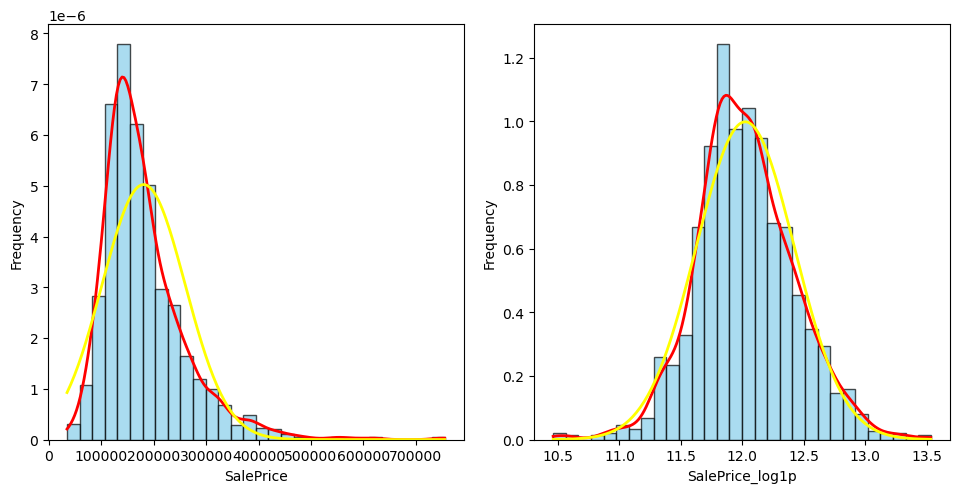

In [27]:
# Plotting distribution
df_data[LOGP_TARGET_COL] = np.log1p(df_data[TARGET_COL])
print(df_data[LOGP_TARGET_COL].describe())
show_distribution(df_data, [TARGET_COL, LOGP_TARGET_COL])
# Distribution is clearly right skewed
# When applying log1p transformation, the distribution becomes more normal
# log1p => Mean ~= Median


Row count 1


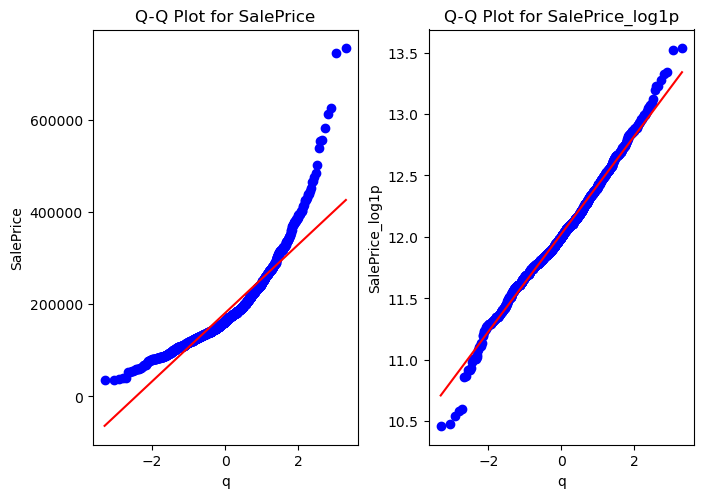

Row count 1


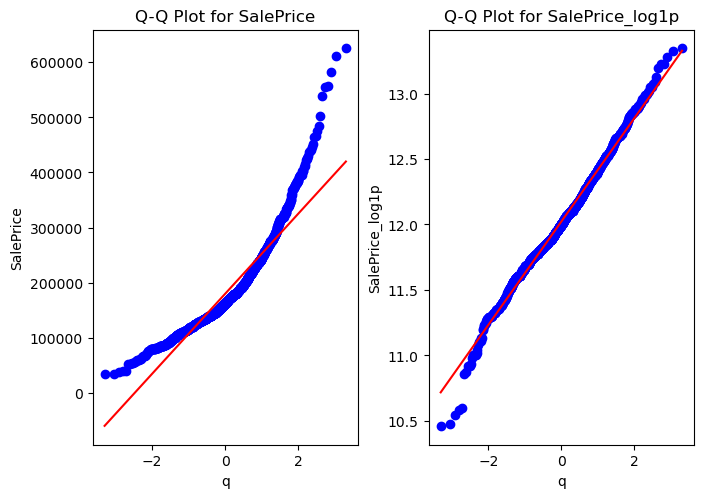

In [28]:
# Q-Q plot to check when the model will struggle
show_qq_plot(df_data, [TARGET_COL, LOGP_TARGET_COL])
# How about removing outliers
df_noout = df_data.copy()[~(df_data["GrLivArea"] > 4000)]

show_qq_plot(df_noout, [TARGET_COL, LOGP_TARGET_COL])
# Observations
# 1. Log1p has some outliers, but distribution is more normal

In [29]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               1460 non-null   int64  
 1   MSSubClass       1460 non-null   int64  
 2   MSZoning         1460 non-null   str    
 3   LotFrontage      1201 non-null   float64
 4   LotArea          1460 non-null   int64  
 5   Street           1460 non-null   str    
 6   Alley            91 non-null     str    
 7   LotShape         1460 non-null   str    
 8   LandContour      1460 non-null   str    
 9   Utilities        1460 non-null   str    
 10  LotConfig        1460 non-null   str    
 11  LandSlope        1460 non-null   str    
 12  Neighborhood     1460 non-null   str    
 13  Condition1       1460 non-null   str    
 14  Condition2       1460 non-null   str    
 15  BldgType         1460 non-null   str    
 16  HouseStyle       1460 non-null   str    
 17  OverallQual      1460 non

In [30]:
# Dropping Id column as it is not needed for training
df_data = df_data.drop(columns=["Id"], errors='ignore')


## Correlation with Target

In [31]:

# Checking positive and negative correlation. Graving more positive values because there are more positive correlations than negative ones.
print(TARGET_COL)
println()
df_corr = df_data.corr(numeric_only=True)[np.abs(df_data.corr(numeric_only=True)[TARGET_COL].values) > 0.5].sort_values(by=TARGET_COL, ascending=False)
print(df_corr[TARGET_COL])
printspace()
print(LOGP_TARGET_COL)
println()
df_corr_logp = df_data.corr(numeric_only=True)[np.abs(df_data.corr(numeric_only=True)[LOGP_TARGET_COL].values) > 0.5].sort_values(by=LOGP_TARGET_COL, ascending=False)
print(df_corr_logp[LOGP_TARGET_COL])
#print(df_corr.shape)

SalePrice
------------------------------
SalePrice          1.000000
SalePrice_log1p    0.948374
OverallQual        0.790982
GrLivArea          0.708624
GarageCars         0.640409
GarageArea         0.623431
TotalBsmtSF        0.613581
1stFlrSF           0.605852
FullBath           0.560664
TotRmsAbvGrd       0.533723
YearBuilt          0.522897
YearRemodAdd       0.507101
Name: SalePrice, dtype: float64
                              
SalePrice_log1p
------------------------------
SalePrice_log1p    1.000000
SalePrice          0.948374
OverallQual        0.817185
GrLivArea          0.700927
GarageCars         0.680625
GarageArea         0.650888
TotalBsmtSF        0.612134
1stFlrSF           0.596981
FullBath           0.594771
YearBuilt          0.586570
YearRemodAdd       0.565608
GarageYrBlt        0.541073
TotRmsAbvGrd       0.534422
Name: SalePrice_log1p, dtype: float64


In [32]:
df_corr_logp[df_corr_logp.index]

,SalePrice_log1p,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,YearBuilt,YearRemodAdd,GarageYrBlt,TotRmsAbvGrd
SalePrice_log1p,1.000000,0.948374,0.817185,0.700927,0.680625,0.650888,0.612134,0.596981,0.594771,0.586570,0.565608,0.541073,0.534422
SalePrice,0.948374,1.000000,0.790982,0.708624,0.640409,0.623431,0.613581,0.605852,0.560664,0.522897,0.507101,0.486362,0.533723
OverallQual,0.817185,0.790982,1.000000,0.593007,0.600671,0.562022,0.537808,0.476224,0.550600,0.572323,0.550684,0.547766,0.427452
GrLivArea,0.700927,0.708624,0.593007,1.000000,0.467247,0.468997,0.454868,0.566024,0.630012,0.199010,0.287389,0.231197,0.825489
GarageCars,0.680625,0.640409,0.600671,0.467247,1.000000,0.882475,0.434585,0.439317,0.469672,0.537850,0.420622,0.588920,0.362289
GarageArea,0.650888,0.623431,0.562022,0.468997,0.882475,1.000000,0.486665,0.489782,0.405656,0.478954,0.371600,0.564567,0.337822
TotalBsmtSF,0.612134,0.613581,0.537808,0.454868,0.434585,0.486665,1.000000,0.819530,0.323722,0.391452,0.291066,0.322445,0.285573
1stFlrSF,0.596981,0.605852,0.476224,0.566024,0.439317,0.489782,0.819530,1.000000,0.380637,0.281986,0.240379,0.233449,0.409516
FullBath,0.594771,0.560664,0.550600,0.630012,0.469672,0.405656,0.323722,0.380637,1.000000,0.468271,0.439046,0.484557,0.554784
YearBuilt,0.586570,0.522897,0.572323,0.199010,0.537850,0.478954,0.391452,0.281986,0.468271,1.000000,0.592855,0.825667,0.095589


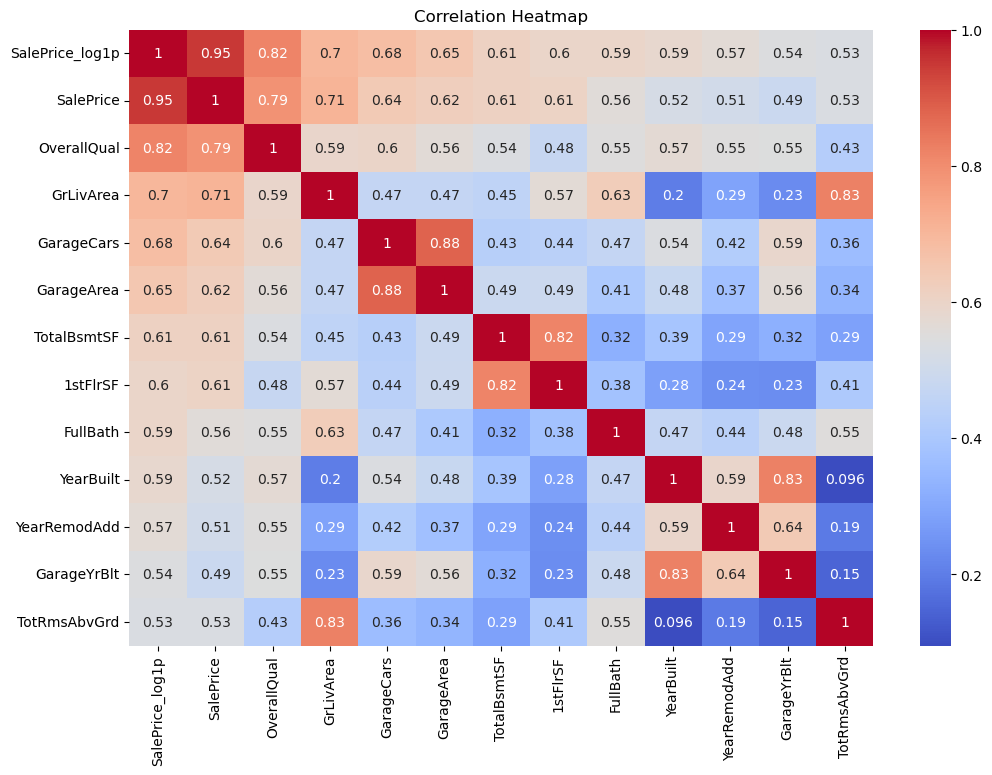

In [33]:
# Let's plot a heatmap to visualize the correlation
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr_logp[df_corr_logp.index], annot=True, cmap="coolwarm") # Plot only columns having more correlation
plt.title("Correlation Heatmap")
plt.show()

# Observations
# OveralQual and GrLivArea are correlated with SalePrice, which makes a lot of sense. Let's play with them after.
# GarageCars and GarageArea are correlated, which maybe indicates that they are redundant?
# CarageCars and GarageArea are correlated with SalePrice too.
# YearBuilt can be used also to create features having more information, like HouseYearsOld
# GarageYrBlt can be also better as GarageYearsOld?
# GrLivArea is correlated with OveralQual, let's try some ratio there
# TotRmsAbvGrd and GrLivArea can be used to create a feature having more information, like RoomsPerArea or similar
# Let's think about YearBuilt and YearRemodAdd
# FullBath and TotRmsAbvGrd can be used to created some BathPerRoomRatio or similar. Also HalfBath can be considered
# TotalBsmtSF and 1stFlrSF corr is very high. Check that relationship.

In [34]:
# Checking Spearman correlation just in case we can find non linear relationships

print(LOGP_TARGET_COL, "Pearson")
println()
print(df_corr_logp[LOGP_TARGET_COL])
printspace()
print(LOGP_TARGET_COL, "Spearman")
println()
df_corr_logp_s = df_data.corr(method="spearman", numeric_only=True)[np.abs(df_data.corr(method="spearman", numeric_only=True)[LOGP_TARGET_COL].values) > 0.5].sort_values(by=LOGP_TARGET_COL, ascending=False)
print(df_corr_logp_s[LOGP_TARGET_COL])
corr_features_target = np.concat((
    df_corr_logp.index.values,
    df_corr_logp_s.index.values
))

corr_features_target = np.unique(corr_features_target)
printspace()
println()
print("Target Corr features:", corr_features_target)

# Observations
# More or less the same, but Fireplaces appeares in the list here. Maybe some signal there? Let's play with that field after

SalePrice_log1p Pearson
------------------------------
SalePrice_log1p    1.000000
SalePrice          0.948374
OverallQual        0.817185
GrLivArea          0.700927
GarageCars         0.680625
GarageArea         0.650888
TotalBsmtSF        0.612134
1stFlrSF           0.596981
FullBath           0.594771
YearBuilt          0.586570
YearRemodAdd       0.565608
GarageYrBlt        0.541073
TotRmsAbvGrd       0.534422
Name: SalePrice_log1p, dtype: float64
                              
SalePrice_log1p Spearman
------------------------------
SalePrice_log1p    1.000000
SalePrice          1.000000
OverallQual        0.809829
GrLivArea          0.731310
GarageCars         0.690711
YearBuilt          0.652682
GarageArea         0.649379
FullBath           0.635957
TotalBsmtSF        0.602725
GarageYrBlt        0.593788
1stFlrSF           0.575408
YearRemodAdd       0.571159
TotRmsAbvGrd       0.532586
Fireplaces         0.519247
Name: SalePrice_log1p, dtype: float64
                          

## Correlation between features

In [35]:
method_feat = {}
corr_features = np.array([], dtype=str)
for method in ["pearson", "spearman"]:
    print(f"Correlation between features using *{method}* method")
    println(n=40)
    df_corr_f = df_data.drop(columns=[TARGET_COL, LOGP_TARGET_COL]).corr(method=method, numeric_only=True)
    df_corr_f = df_corr_f.where((df_corr_f.abs() > 0.6) & (df_corr_f != 1))
    df_corr_f_list = df_corr_f.stack().sort_values(ascending=False).reset_index().rename(columns={0: "Correlation", "level_0": "Feature1", "level_1": "Feature2"})
    # Remove rows duplicated correlations in inverse order
    df_corr_f_list = df_corr_f_list[df_corr_f_list.index % 2 == 1]
    corr_features = np.append(corr_features, pd.concat((df_corr_f_list["Feature1"], df_corr_f_list["Feature2"])).drop(columns="index").values)
    corr_features = np.unique(corr_features)
    feat = df_corr_f_list["Feature1"].str.cat(df_corr_f_list["Feature2"], sep="_")
    method_feat[method] = feat
    
    print("High correlation list")
    println(n=40)
    print(df_corr_f_list.reset_index().drop(columns=["index"]))
    printspace()
    # Using all to remove rows and columns having all NaN values and fill missing with 0 to display the heatmap
    df_corr_f = df_corr_f.dropna(how="all", axis=0).dropna(how="all", axis=1).fillna(0) 
# print("Pearson:", np.setdiff1d(method_feat["pearson"], method_feat["spearman"]))
# println()
# print("Spearman:", np.setdiff1d(method_feat["spearman"], method_feat["pearson"]))
printspace()
println()
print("Total features having high correlation:", len(corr_features))
print(corr_features)

# Observations
# Features here are more or less the same as in the correlation with the target
# CarageArea and GarageCars are very strongly correlated. Perhaps because the explain more or less the same. Let's try creating a ratio like SizeForEachCar or something
# Area and SF features are correlated between each other (TotalBsmtSF, 1stFlrSF, BsmtFinSF1, 2ndFlrSF, GrLivArea, GarageArea, LotArea). Some of them have corr with Target too.
# --> we can try to combine some or many of them to see what happens.
# Spearman shows some more features. Let's check if the is some monotonic relationship there.





Correlation between features using *pearson* method
----------------------------------------
High correlation list
----------------------------------------
          Feature1       Feature2  Correlation
0       GarageArea     GarageCars     0.882475
1      GarageYrBlt      YearBuilt     0.825667
2     TotRmsAbvGrd      GrLivArea     0.825489
3      TotalBsmtSF       1stFlrSF     0.819530
4        GrLivArea       2ndFlrSF     0.687501
5     TotRmsAbvGrd   BedroomAbvGr     0.676620
6       BsmtFinSF1   BsmtFullBath     0.649212
7      GarageYrBlt   YearRemodAdd     0.642277
8         FullBath      GrLivArea     0.630012
9         2ndFlrSF   TotRmsAbvGrd     0.616423
10        2ndFlrSF       HalfBath     0.609707
11      GarageCars    OverallQual     0.600671
12      MSSubClass    LotFrontage          NaN
13      MSSubClass    OverallQual          NaN
14      MSSubClass      YearBuilt          NaN
15      MSSubClass     MasVnrArea          NaN
16      MSSubClass     BsmtFinSF2          Na

## Data structure Analysis

In [36]:
feSF = ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "GrLivArea", "GarageArea", LOGP_TARGET_COL]
# BuiltSF should be correlated to target
df_data["BuiltSF"] = df_data["1stFlrSF"] + df_data["2ndFlrSF"] + df_data["GarageArea"] + df_data["TotalBsmtSF"]
# Let's check if the built Area / SF ratio has some meaning
df_data["BuiltRatio"] = df_data["LotArea"] / df_data["BuiltSF"] 
df_data["NonBuiltSF"] = df_data["LotArea"] - df_data["BuiltSF"]
floorSF = ["BuiltRatio", "BuiltSF", LOGP_TARGET_COL]
#sns.pairplot(df_data[floorSF], hue=LOGP_TARGET_COL)
df_data[["BuiltSF", "BuiltRatio", LOGP_TARGET_COL]].corr(method="spearman")

# Does ratio has any non linear relationship?
print("MI BuiltRatio:", mutual_info_regression(df_data[["BuiltRatio"]], df_data[LOGP_TARGET_COL], discrete_features=False))

df_data[["NonBuiltSF", LOGP_TARGET_COL]].corr()

#sns.pairplot(df_data[["NonBuiltSF", LOGP_TARGET_COL]])

# Observations
# BuiltSF has high correlation with target (as expected)
# BuildRatio has none "Pearson" correlation and a very low "Spearman" correlation with target
# There is no clear linear / monotonic relationship with BuildRatio and BuildSF
# There is no relationship between BuiltRatio and the target
# There is no relationship between NonBuiltSF and the target

MI BuiltRatio: [0.10329675]


,NonBuiltSF,SalePrice_log1p
NonBuiltSF,1.000000,0.183958
SalePrice_log1p,0.183958,1.000000


## Corr target / Pairplots

['1stFlrSF', 'Fireplaces', 'FullBath', 'GarageArea', 'GarageCars', 'GarageYrBlt', 'GrLivArea', 'OverallQual', 'SalePrice', 'SalePrice_log1p', 'TotRmsAbvGrd', 'TotalBsmtSF', 'YearBuilt', 'YearRemodAdd', 'MSSubClass']


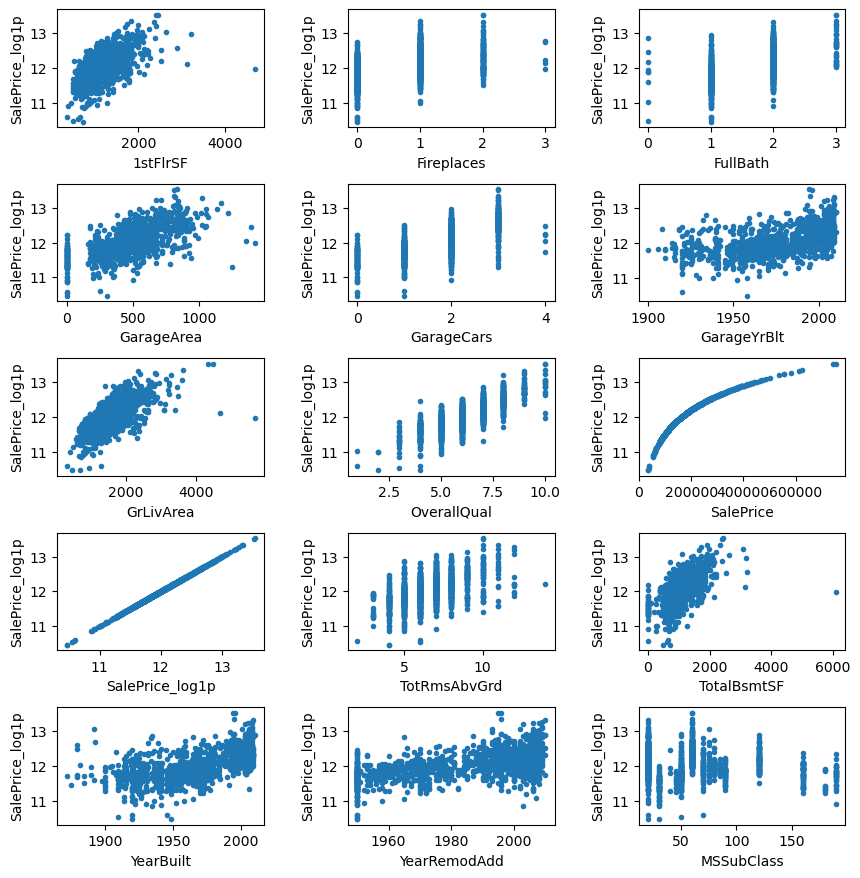

In [37]:
pp_feat = corr_features_target.tolist() + ["MSSubClass"]
print(pp_feat)
show_target_pairplot(df_data, pp_feat, LOGP_TARGET_COL)

# There are some outliers in 1stFlrSF, BuiltSF, GarageArea, GrLiveArea, TotalBsmtSF
# Fireplaces. 3 is not a common value. Test making it 2.
# What does fullbath == 0 means? Seems wrong value. Check.
# A lot of 0 in Fireplaces, FullBath, GarageArea, GarageCars, YearRemodAdd, TotalBsmtSF
# YearBuilt and YearRemodAdd are kind of noicy. 
# MSSubClass seems to have some signal. Check ANoVA. There are some very low values (out of trend) for some categories.

## Checking main features distribution

Corr lenght: 38
0 6


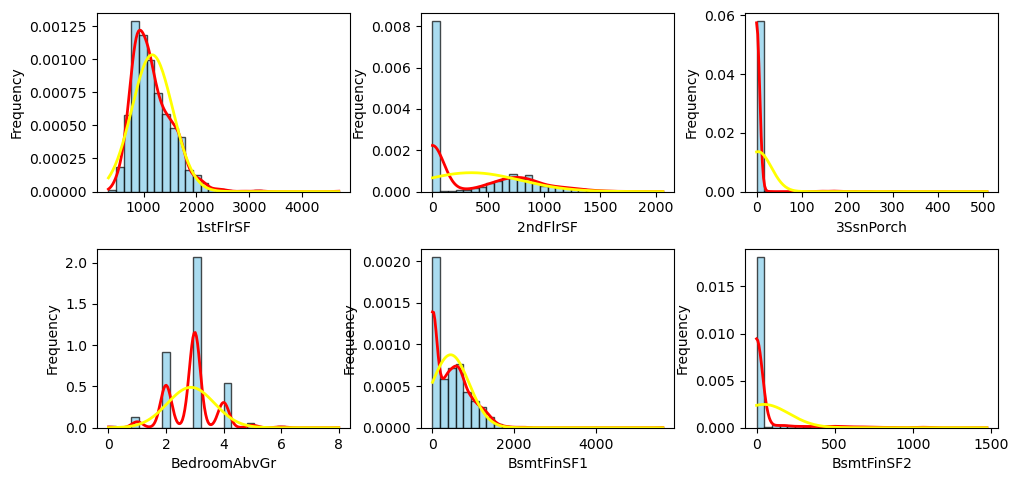

6 12


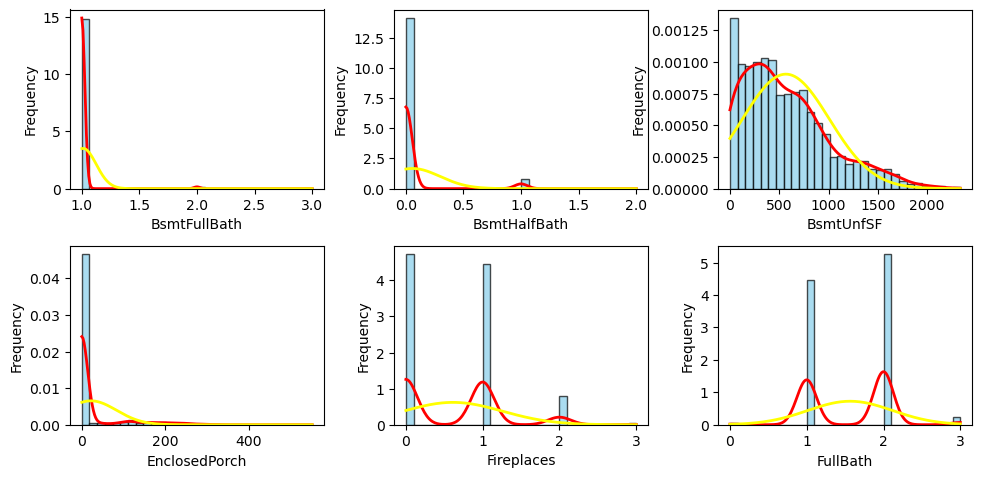

12 18


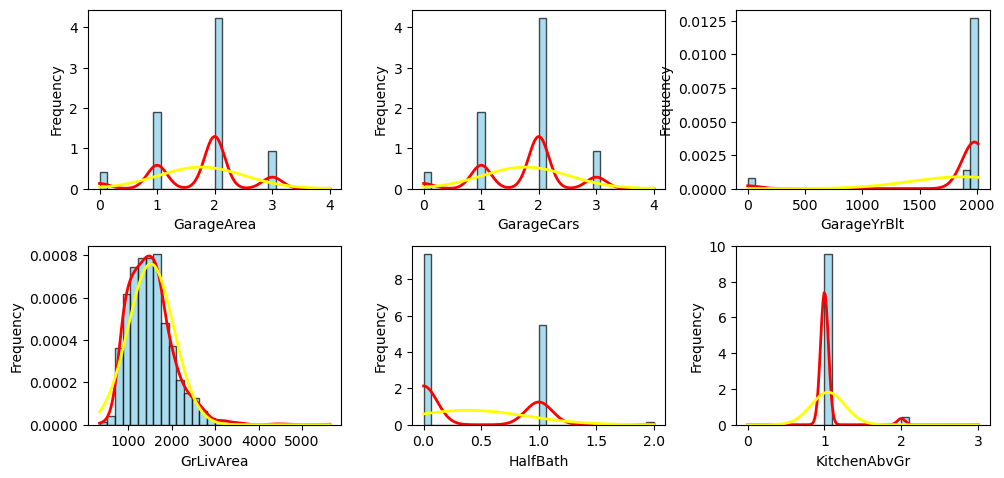

18 24


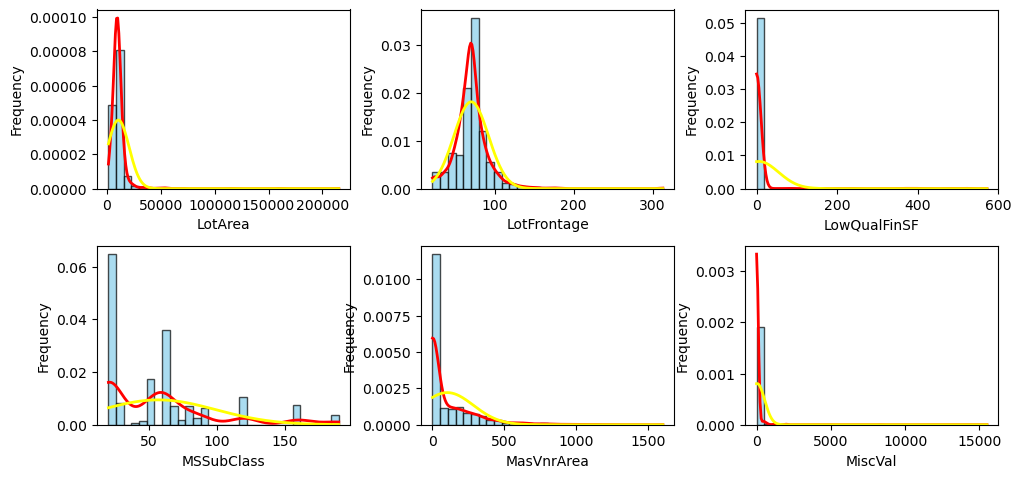

24 30


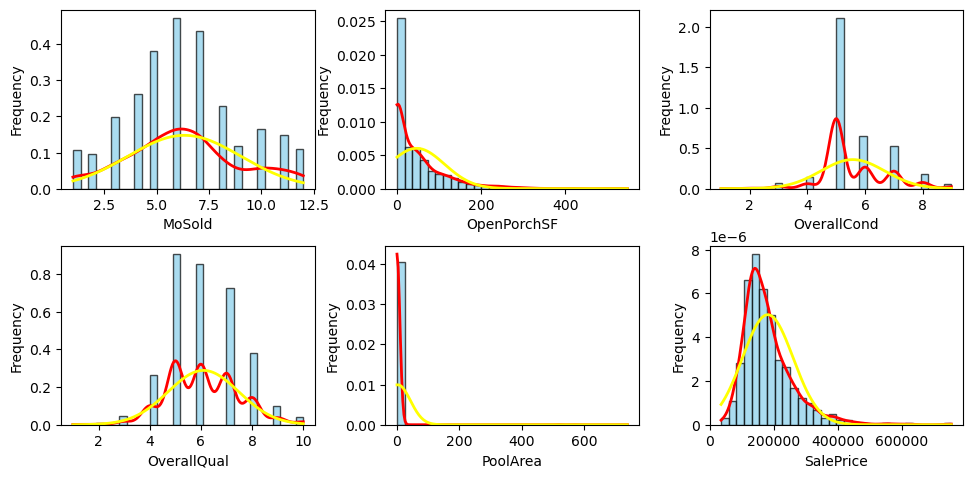

30 36


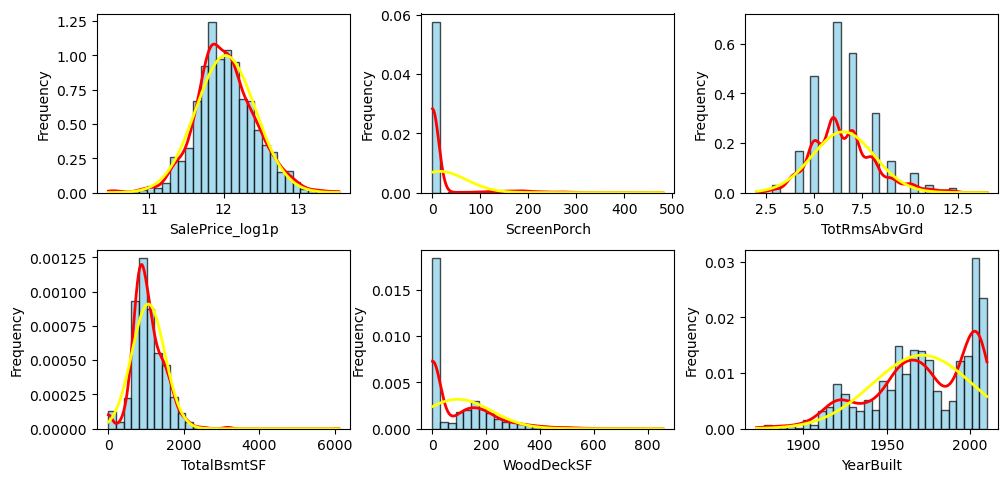

36 37


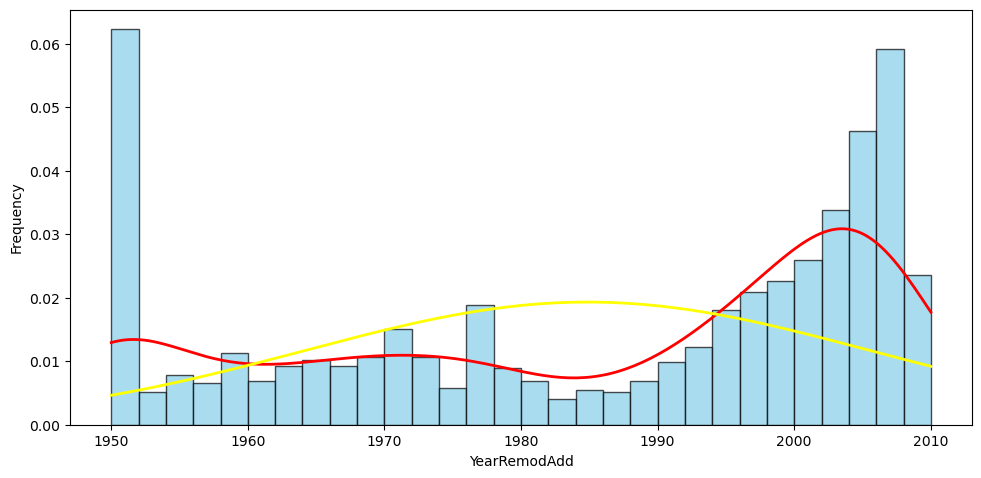

In [38]:
all_corr = np.unique(np.concatenate((corr_features_target, corr_features)))
corr_len = len(all_corr)
print("Corr lenght:", corr_len)

df = fix_nulls(df_data, df_data)

step = 6
s = 0 
e = step 
for i in range(s, corr_len, step):
    print(s, e)
    show_distribution(df_data, all_corr[s:e].tolist())
    s+=step
    e = min(s+step, corr_len - 1)

# Observations
# 1stFlrSF is heavy right skewed. Need to check outliers. Also it seems to have the same information than GrLivArea. Check removing or fixing the right skeew using log1p
# 2ndFlrSF is right skewed and it has a lot of 0. Suppose corresponds to houses not having 2nd floor. Maybe create a Has2ndFloor feature? Also check outliers.
# GarageCars and GarageArea should provide the similar information. Try removing or using some combination. There are also several values = 0. Complement with field HasGarage 1/0
# There are a few samples having 3 bathrooms. Check if the related price. Consider creating a Has3Baths feature, or clipping value to 2.
# HalfBath mostly 0-1. Consider HasHalfBath
# Check 0 values in BedroomAbvGr
# BsmtFinSF1 has a lot of 0. Add HasBsmt 1/0. 
# Compare garage built with house built year. Check if has any signal.
# FullBath, a very few values > 2. Check signal. Consider adding HasFullBath
# LotArea has 0 values? If yes, fix. Not possible data
# ScreenPorch, MiscVal, LowQualFinSF, KitchenAbvGr, 3ssnPorch, LowQualFinSF, EnclosedPorch, BsmtFinSF2, BsmtFullBath and BsmtHalfBath are almost constant. Check removal 
# LotArea, LotFrontage, OpenPorchSF, WoodDeckSF, TotalBsmtSF heavy right skewed. -> Log1p?
# PoolArea, OpenPorchSF, WoodDeckSF mostly 0. Add binary
# YearBuilt is left skewed... Transformation?
# What to do with YearRemodAdd?

### Transformation analysis

No Transf
                 GrLivArea   LotArea  1stFlrSF  PoolArea  LotFrontage  \
GrLivArea         1.000000  0.263116  0.566024  0.170205     0.368392   
LotArea           0.263116  1.000000  0.299475  0.077672     0.306795   
1stFlrSF          0.566024  0.299475  1.000000  0.131525     0.414266   
PoolArea          0.170205  0.077672  0.131525  1.000000     0.180868   
LotFrontage       0.368392  0.306795  0.414266  0.180868     1.000000   
OpenPorchSF       0.330224  0.084774  0.211671  0.060762     0.137454   
WoodDeckSF        0.247433  0.171698  0.235459  0.073378     0.077106   
TotalBsmtSF       0.454868  0.260833  0.819530  0.126053     0.363358   
SalePrice_log1p   0.700927  0.257320  0.596981  0.069798     0.336156   

                 OpenPorchSF  WoodDeckSF  TotalBsmtSF  SalePrice_log1p  
GrLivArea           0.330224    0.247433     0.454868         0.700927  
LotArea             0.084774    0.171698     0.260833         0.257320  
1stFlrSF            0.211671    0.235459

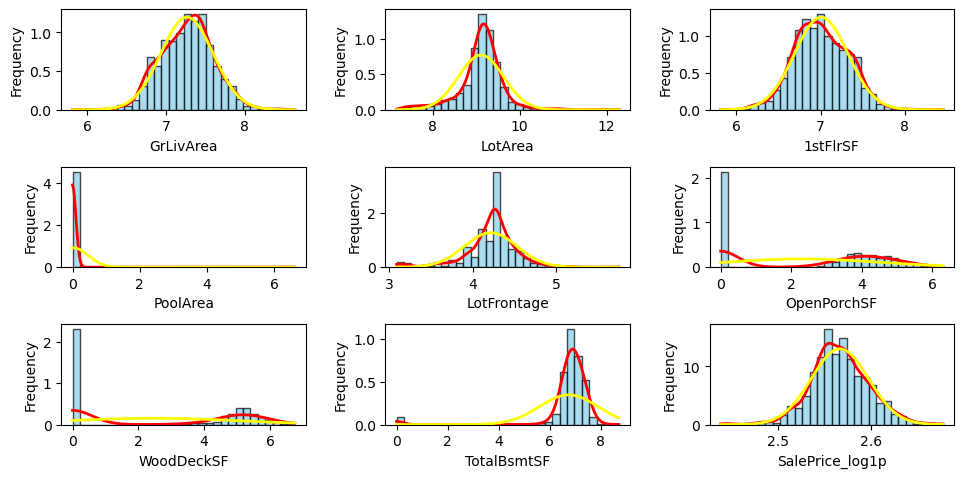

In [39]:
# From the previous graphics where GarageArea, GrLivArea, LotArea, LotFrontage and 1stFlrSF can be transformed. Let's check skew and see.
# Also check BsmtFinSF1 and BsmtUnfSF
# ScreenPorch, MiscVal, LowQualFinSF, KitchenAbvGr, 3ssnPorch, LowQualFinSF, EnclosedPorch, BsmtFinSF2, BsmtFullBath and BsmtHalfBath are almost constant. Check removal 
# LotArea, LotFrontage, OpenPorchSF, WoodDeckSF, TotalBsmtSF heavy right skewed. -> Log1p?
# PoolArea, OpenPorchSF, WoodDeckSF mostly 0. Add binary
# YearBuilt is left skewed... Transformation?
# What to do with YearRemodAdd?

df = fix_nulls(df_data, df_data)
df = df[df["GrLivArea"] < 4000]
sk_cols = ["GarageArea", "GrLivArea", "LotArea", "1stFlrSF", "YearBuilt", "PoolArea", "LotFrontage", "OpenPorchSF", "WoodDeckSF", "TotalBsmtSF"]
sk_cols = df[sk_cols].columns[df_data[sk_cols].skew().abs() > 0.75].tolist()
sk_cols.append(LOGP_TARGET_COL)

df_sk = df_data[sk_cols]
df_tsk = df_data[sk_cols].apply(lambda x: np.log1p(x))

print("No Transf")
print(df_sk.corr())
printspace()
print("Log1p")
println()
print(df_tsk.corr())

#show_distribution(df_data, all_corr[18:22].tolist())
show_distribution(df_tsk, sk_cols)

# Observations
# - GrLiveArea, LotArea, LotFrontage and 1stFlrSF distributions is much more normal after applying log1p
# - BsmtFinSF1 and BsmtUnfSF1 become left skewed. Let's try sqrt
# - Correlation is improved a little bit


### Categories

#### Functions

In [40]:
def print_cardinal_info(X, Y, feat):
  df_proc = X.join(Y)
  logpm = df_proc[LOGP_TARGET_COL].mean()
  res = {"val": [], "porc": [], "tg_mean": [], "var": [], "count": []}

  for val in  np.sort(df_proc[feat].unique()):
    df_val = df_proc[df_proc[feat] == val]
    porc =  df_val.shape[0] / df_proc.shape[0]
    tg_mean = df_val[LOGP_TARGET_COL].mean()
    var = df_val[LOGP_TARGET_COL].var()
    count = df_val.shape[0]

    res["val"].append(val)
    res["porc"].append(porc)
    res["tg_mean"].append(tg_mean)
    res["var"].append(var)
    res["count"].append(count)

  df_res = pd.DataFrame(res)
  print("Feature:", feat)
  println()
  for i, row in df_res.sort_values(by="tg_mean", ascending=False).iterrows():
    # copy values from row to variables
    val = row["val"]
    porc = row["porc"]
    tg_mean = row["tg_mean"]
    var = row["var"]
    count = row["count"]
    print(f"val: {val}", f"({pfmt(porc)}) - target mean: {nfmt(tg_mean)}", "var:", f"{nfmt(var)}", "count:", count)
  printspace()

#### Ordinal categories

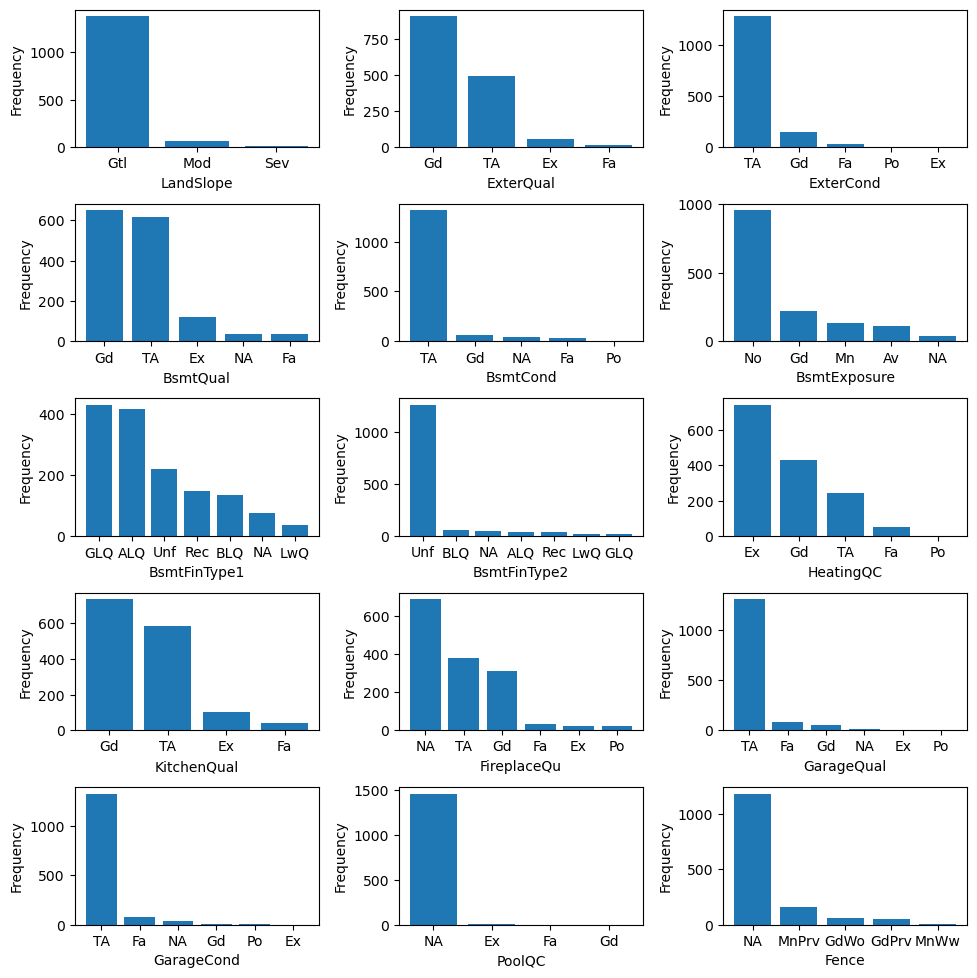

In [41]:
# Ordinal categories

#df_data[ORD_COLS].hist()
show_bar_plot(df_data, ORD_COLS)


# Observations
# LandSlope has 1 very dominant category. Maybe transform to IsLandSlopeGtl? Check signal
# OverallQual has a few low values. Check group in 3
# OverallCond, 5 is dominant and lower that 5 weard. Maybe create Low/Medium/Hight? 1/5/10 or something to maintain meaningful difference?
# ExterQual, Gd and TA are dominant. Low/Medium/Large could be applied here.
# ExterCond, same as ExterQual
# BsmtQual, Maybe here the values make more sense even having 2 dominant categories. Also NA means no basement. Should add HasBsmt field?
# BsmtCond, TA is extremelly dominant. Maybe is IsBsmtQualCondTypica and HasBsmt field?
# BsmtExposure, No (No exposure) is dominant, and other values exists. Try HasBsmtExposure field.
# BsmtFinType1, There are two dominant categories, but all off them have values. Keep as it is?
# BsmtFinType2, Unf (Unfinished) is very dominant. Check creating HasBsmtFinType2
# HeatingQC, Fa and Po has very low values. Test creating "Other" value or making Fa and Po = TA
# KitchenQual, leave as it is
# FireplaceQu, NA is dominant. Maybe create HasFireplace field and High/Medium/Low categories
# GarageQual, TA is dominant and has very few values different than that. Check removing the feature
# GarageCond, same than GarageQual
# PoolQC, NA is the 99% of the rows. Remove it. Just in case, check if the other 1% behaves very diffently in relation with the target. Create HasPool feature




In [42]:
# X = X.join(Y)
# show_target_pairplot(X, ["BalOverallQual"], LOGP_TARGET_COL)

#### Class Categories

In [43]:
def get_class_categories_feat(df):
    """
    Get class categories from the DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing the data.

    Returns:
        list: List of class categories.
    """
    num_feat = df.select_dtypes(include=[np.number]).columns
    class_cat = [x for x in df.columns if x not in num_feat and x not in ORD_COLS]
    return class_cat

def print_class_cat_summary(df):
  for col in class_cat:
    println()
    print(df[col].value_counts())
    printspace()

def analyze_cat_dist(df, print_output=True):
  one_row_val_cols = []
  ext_imb_cols = []
  hei_imb_cols = []
  bin_cols = []
  const_cols = []
  tot = df.shape[0]
  for col in class_cat:
    vc = df[col].value_counts()
    data = {
      "value": vc.index,
      "count": vc.values
    }
    df_vc = pd.DataFrame(data)
    PORC_COL = "porc"
    df_vc[PORC_COL] = df_vc["count"] * 100 / tot

    if df_vc[PORC_COL].max() > 99.0:
      const_cols.append(col)
    elif df_vc[PORC_COL].max() > 95.0:
      ext_imb_cols.append(col)
    elif df_vc[PORC_COL].max() > 70.0:
      hei_imb_cols.append(col)

    if vc.shape[0] < 3:
      bin_cols.append(col)

    if df_vc[df_vc["count"] == 1].shape[0] > 0:
      one_row_val_cols.append(col)

  if print_output:
    print("Extreamly imbalanced columns:")
    println()
    print(ext_imb_cols)
    printspace()
    print("Highly imbalanced columns:")
    println()
    print(hei_imb_cols)
    printspace()
    print("Binary columns:")
    println()
    print(bin_cols)
    printspace()
    print("Constant columns:")
    println()
    print(const_cols)
    printspace()
    print("Unique row columns:")
    println()
    print(one_row_val_cols)
  # Return categories to be analized deeply
  return one_row_val_cols, ext_imb_cols, hei_imb_cols, bin_cols, const_cols

In [44]:
# Low cols: ['MSZoning', 'Alley', 'Exterior2nd', 'MiscFeature']
# Categories for col MSZoning : ['A', 'C', 'FV', 'I', 'RH', 'RL', 'RP', 'RM']
# Categories for col Alley : ['Grvl', 'Pave', 'NA']
# Categories for col Exterior2nd : ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Other', 'Plywood', 'PreCast', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'WdShing']
# Categories for col MiscFeature : ['Elev', 'Gar2', 'Othr', 'Shed', 'TenC', 'NA']
# Low cols: ['MSZoning', 'Alley', 'Exterior2nd', 'MiscFeature']
# Categories for col MSZoning : ['A', 'C', 'FV', 'I', 'RH', 'RL', 'RP', 'RM']
# Categories for col Alley : ['Grvl', 'Pave', 'NA']
# Categories for col Exterior2nd : ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Other', 'Plywood', 'PreCast', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'WdShing']
# Categories for col MiscFeature : ['Elev', 'Gar2', 'Othr', 'Shed', 'TenC', 'NA']


In [45]:
class_cat = get_class_categories_feat(df_data) 
# print("Class categories")
# println()
# print(class_cat)

#print_class_cat_summary(df_data)

oner, extim, heim, bin, const = analyze_cat_dist(df_data)

Extreamly imbalanced columns:
------------------------------
['Condition2', 'RoofMatl', 'Heating', 'MiscFeature']
                              
Highly imbalanced columns:
------------------------------
['MSZoning', 'Alley', 'LandContour', 'LotConfig', 'Condition1', 'BldgType', 'RoofStyle', 'CentralAir', 'Electrical', 'Functional', 'PavedDrive', 'SaleType', 'SaleCondition']
                              
Binary columns:
------------------------------
['Street', 'Utilities', 'CentralAir']
                              
Constant columns:
------------------------------
['Street', 'Utilities']
                              
Unique row columns:
------------------------------
['Utilities', 'Condition2', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Heating', 'Electrical', 'Functional', 'MiscFeature']


In [46]:

onerow, extim, heim, binc, const = analyze_cat_dist(df_data, print_output=False)
X = df_data.copy().drop(columns=LOGP_TARGET_COL)
Y = df_data[LOGP_TARGET_COL].copy()

# Rest of the columns
lowim = [x for x in class_cat if x not in (oner + extim + heim + binc + const)]
print("Other columns", lowim)

# for col in heim:
#      print_cardinal_info(X, Y, col)

def compute_mi(X, Y, feats, label):
  enc = LabelEncoder()
  X_enc = X[feats].copy()
  for col in feats:
    X_enc[f"enc_{col}"] = enc.fit_transform(X_enc[col])
  X_enc = X_enc.drop(columns=feats)
  mi = list(zip(feats, np.round(mutual_info_regression(X_enc, Y), 4)))
  df_mi = pd.DataFrame(mi, columns=["feature", "mi"]).sort_values(by="mi", ascending=False)
  df_mi["type"] = label 
  return df_mi 

df_mi = compute_mi(X, Y, extim, "extreme")
df_mi = pd.concat([df_mi, compute_mi(X, Y, heim, "high")])
df_mi = pd.concat([df_mi, compute_mi(X, Y, lowim, "low")])

df_mi = df_mi.sort_values(by="mi", ascending=False)
df_mi
#df_mi["feature"].tolist()



#show_target_pairplot(df_data, onerow, LOGP_TARGET_COL)
 
# X = df_data.copy().drop(columns=LOGP_TARGET_COL)
# Y = df_data[LOGP_TARGET_COL].copy()
#print_cardinal_info(X, Y, "Utilities")

# Observations:
# - Almost constant: Street, Utilities
# - Extreamelly imbalanced: MSZoning, Alley, LandCountour, Condition2, RoofMatl, Heating, CentralAir, PavedDrive
# - Highly imbalanced:  Condition1, BldgType, RoofStyle, Electrical, Functional, Fence, MiscFeature, SaleType
# - Imbolanced: LotShape, LotConfig, Neigbourhood, HouseStyle, Exterior1st, Exterior2nd, GarageType, SaleCondition
# - CentralAir is a binary category (S/N)
# - PavedDrive can be converted as a binary
# - Neigbourhood, Condition1 have values with a very few rows.
# - Condition2, RoffMat1 have values with only one row and also is extremely imbalanced
# - PaveDrive is not binary, but it can be converted to binary. It can be HasPaveDrive (1/0) instead of three values. Analyze values P and N
# - Street column is almost constant. It has only one row == NoSeWa. Even when Sale Price is different is not usable



Other columns ['LotShape', 'Neighborhood', 'HouseStyle', 'MasVnrType', 'Foundation', 'GarageType', 'GarageFinish']


,feature,mi,type
1,Neighborhood,0.5045,low
6,GarageFinish,0.2700,low
5,GarageType,0.2021,low
4,Foundation,0.1956,low
0,MSZoning,0.1282,high
3,MasVnrType,0.1023,low
2,HouseStyle,0.0873,low
11,SaleType,0.0844,high
0,LotShape,0.0834,low
12,SaleCondition,0.0742,high


## Outliers

### Analysis

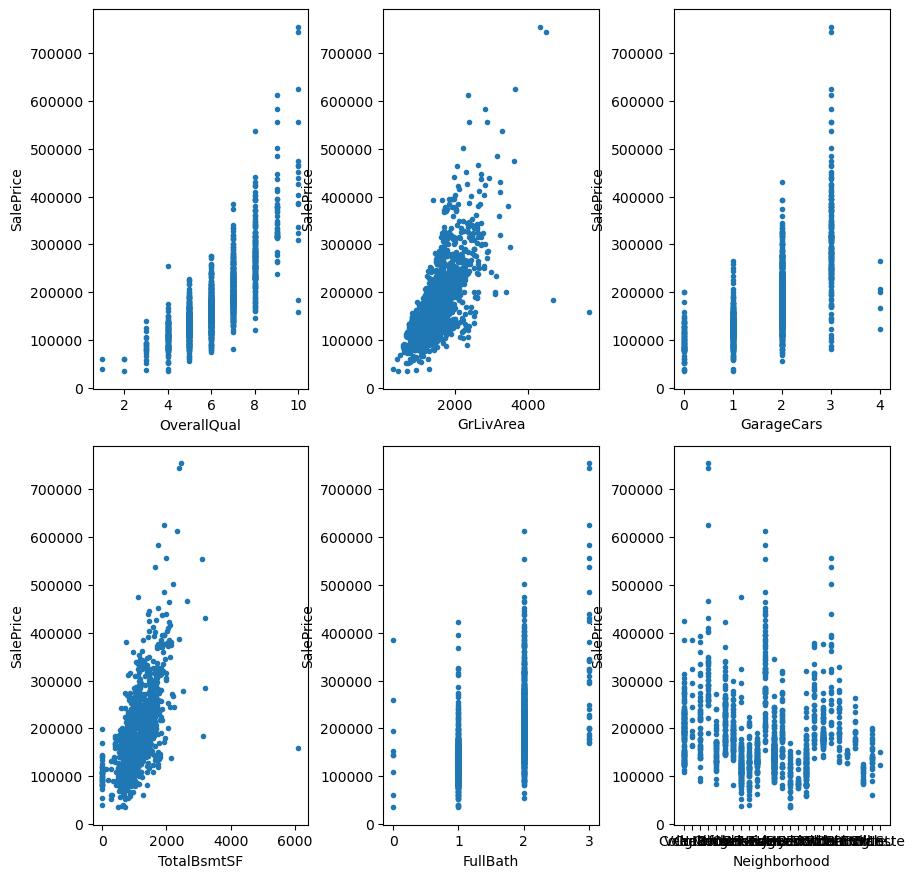

In [47]:
# From previous analysis
# Correlation ---------------
# OverallQual        0.790982
# GrLivArea          0.708624
# GarageCars         0.640409
# GarageArea         0.623431
# TotalBsmtSF        0.613581
# 1stFlrSF           0.605852
# FullBath           0.560664
# TotRmsAbvGrd       0.533723
# YearBuilt          0.522897
# YearRemodAdd       0.507101
# MI ------------------------
# neighbourhood      0.5059


plot_feat = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "FullBath", "Neighborhood"]
show_target_pairplot(df_data, plot_feat, TARGET_COL)


# Observations
# There are some very low SalePrice for a few houses with OverallQual == 10. 
# There a couple of suspicius low price houses having a very big GrLivAre. Maybe is an old house, the OveralQual or they are  the same having a high OverallQual and is a data error?
# A few houses having 4 carage cars and the price is very low. These values are not following the general trend.
# TotalBsmtSF has a similar shape than GrLivArea, but has an outlier with a lot of SF and a very low price. 
# There are two prices higher thant 700.000, corresponding to high standard features. However, the sd still is very high, it might worth trying winsorization.
# YearBuilt and YearRemodAdd are kind of noisy. 

### Functions

In [48]:
def get_iqr(df, feature):
  q1, q3 = df[feature].quantile([0.25, 0.75])
  iqr = q3 - q1
  return q1, q3, iqr

def get_iqr_bounds(q1, q3, iqr, interval=1.5):
    lower = q1 - interval * iqr
    upper = q3 + interval * iqr
    return lower, upper


def remove_outliers(df_rem, features, interval=1.5):
    df = df_rem.copy()
    updated = False
    for col in features:
        skew = df[col].skew()
        #print(col, "Skew:", skew)
        if abs(skew) > 0.5:
            q1, q3, iqr = get_iqr(df, col)
            lower, upper = get_iqr_bounds(q1, q3, iqr, interval=interval)        
            #print(col, "q1", q1, "q3: ", q3)
            #print(col, "iqr", iqr, "lower: ", lower, "upper: ", upper)
            # print("Outliers up: ", df[df[col] > upper][col].count())
            # print("Outliers low: ", df[df[col] < lower][col].count())
    
            old_cnt = df.shape[0]
            df_rem = df[df[col] <= lower]
            df_rem = df[df[col] >= upper]
            df = df[df[col] > lower]
            df = df[df[col] < upper]
    
            #print(old_cnt - df.shape[0], "Outliners Rows removed for col", col)
        if not updated:
          # print("New shape", df.shape)
          # print(df_rem.shape[0]- df.shape[0], "Outliners Rows removed in total")
        #else:
          # print("No rows removed")
          df_rem = df_rem[~df_rem.index.isin(df.index)]
        return df, df_rem

### Tests

In [49]:
# Let try fixing the spoted values and plot again
df = df_data.copy()
df = df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 200000))]
# Now the plots looks better
# GarageCars == 4 is not given usefull information, let's try to change it to 3 and see
df["GarageCars"] = df["GarageCars"].replace(4, 3)


# Let's try winorization with values over 99.5% quantile
if False:
  q = df["SalePrice"].quantile(0.99)
  print("Winsorization q:", q)
  df["SalePrice"] = df["SalePrice"].apply(lambda x: q if x > q else x)

# Capping by value
if True:
  df = df[df["SalePrice"] < 700000]
  
# NoRidge neighborhood outilers analysis
if False:
  # Neighborhood = NoRidge
  df[df["SalePrice"] > 700000]["Neighborhood"]
  print(df[df["Neighborhood"] == "NoRidge"]["SalePrice"].mean())
  print(df[df["Neighborhood"] == "NoRidge"]["SalePrice"].std())
  
  dfr = df[df["Neighborhood"] == "NoRidge"]
  dfr["zscore"] = dfr["SalePrice"].apply(lambda x: (x - dfr["SalePrice"].mean()) / dfr["SalePrice"].std())
  dfr[["SalePrice", "zscore"]].sort_values(by="SalePrice", ascending=False).head(10)

# Removing Outliers using IQR
if False:
  df, dfrem = remove_outliers(df, ["SalePrice"])

df.head()

#show_target_pairplot(df, plot_feat, TARGET_COL)
#show_target_pairplot(df, plot_feat, LOGP_TARGET_COL)
# Check new correlation
#df_corr_logp = df.corr(numeric_only=True)[np.abs(df.corr(numeric_only=True)[LOGP_TARGET_COL].values) > 0.5].sort_values(by=LOGP_TARGET_COL, ascending=False)
#print(df_corr_logp[LOGP_TARGET_COL])

# Observations
# Removing outliers based on GrLivArea also improves plots
# Clipping GaragetCars to 3 seems to make plots better
# Applying winsorization of 0.999 to SalePrice for very hight values makes the plots a little bit better. Same capping values > 700000
# Even using LOGP target, the high prices for NoRidge Neigborhood looks are souspicius
# Final shape applying IQR is good, but a lot of rows are removed
# Correlation has improved after this changes

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log1p,BuiltSF,BuiltRatio,NonBuiltSF
0,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NA,Attchd,2003.0,RFn,2,2,TA,TA,Y,0,61,0,0,0,0,NA,NA,NA,0,2,2008,WD,Normal,208500,12.247699,3114,2.713552,5336
1,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,1,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,2,TA,TA,Y,298,0,0,0,0,0,NA,NA,NA,0,5,2007,WD,Normal,181500,12.109016,2984,3.217158,6616
2,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,2,TA,TA,Y,0,42,0,0,0,0,NA,NA,NA,0,9,2008,WD,Normal,223500,12.317171,3314,3.394689,7936
3,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,3,TA,TA,Y,0,35,272,0,0,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000,11.849405,3115,3.065811,6435
4,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,3,TA,TA,Y,192,84,0,0,0,0,NA,NA,NA,0,12,2008,WD,Normal,250000,12.429220,4179,3.412300,10081


## Normalization

In [50]:

#log1p_cols = ["GarageArea", "GrLivArea", "LotArea", "LotFrontage", "1stFlrSF"]

df_norm = df_data.copy()

df_norm.drop([LOGP_TARGET_COL, TARGET_COL], axis=1, inplace=True)
norm_cols = [col for col in df_norm.columns[df_norm.dtypes != "str"] if col not in ["GarageArea", "GrLivArea", "LotArea", "LotFrontage", "1stFlrSF"]]


#df_norm.dtypes


## Residuals

### Functions

In [364]:
def study_residuals(X, y, model, remove_idx=None):
  if remove_idx is not None:
    X = X[~X.index.isin(remove_idx)]
    y = y[~X.index.isin(remove_idx)]

  pip = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features)
  Xt = pip.fit(X, y).transform(X)

  preds = model.fit(Xt, y).predict(Xt)
  residuals =  y - preds
  plt.scatter(preds, residuals, alpha=0.5)
  plt.axhline(0, color='red')
  plt.xlabel("Predicted")
  plt.ylabel("Resisuals")
  plt.show()


  df_res = pd.DataFrame({
    "y": y,
    "pred": preds,
    "residual": residuals
  }, index=X.index)

  df_res["abs_res"] = np.abs(df_res["residual"])
  df_res["bin"] = pd.qcut(df_res["pred"], 5)
  return df_res

### Ridge

Model: Ridge
Parameters: {'alpha': 1.592282793341094, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}


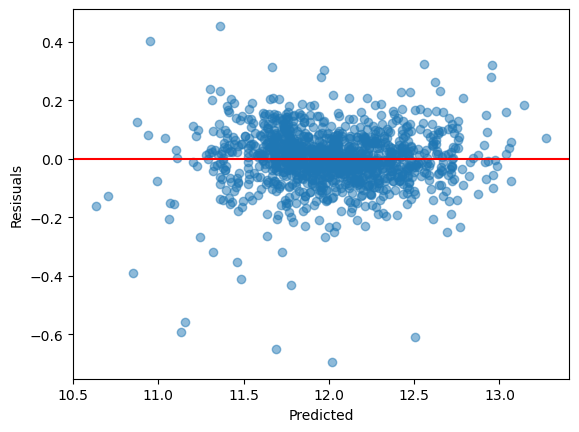

bin
(10.631, 11.708]    0.091908
(11.708, 11.899]    0.067304
(11.899, 12.105]    0.059078
(12.105, 12.345]    0.062212
(12.345, 13.276]    0.071877
Name: abs_res, dtype: float64


,y,pred,residual,abs_res,bin
1403,12.552930,12.463063,0.089867,0.089867,"(12.345, 13.276]"
1312,12.618186,12.657250,-0.039064,0.039064,"(12.345, 13.276]"
680,11.870607,11.767832,0.102775,0.102775,"(11.708, 11.899]"
639,12.485831,12.438454,0.047377,0.047377,"(12.345, 13.276]"
247,11.849405,11.904579,-0.055174,0.055174,"(11.899, 12.105]"


In [381]:
X, y, y_orig, X_test, y_test = split_train_test_data()
X, y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, y, y_orig)


# Removing residuals > 0.2 an see what happen.
# nrows_b = X.shape[0]
# X = X[~X.index.isin(bigres_idx)]
# y = y[~y.index.isin(bigres_idx)]

# print("Removed rows:", nrows_b - X.shape[0], "(", nfmt((nrows_b - X.shape[0]) / nrows_b * 100), "%)")

dfres = study_residuals(X, y, model=get_model("Rig"))


print(dfres.groupby("bin")["abs_res"].mean())
#print(df_res.groupby("bin")["abs_res"].mean())

dfres.head()

In [382]:

res_filter = 0.35
bigres_idx = dfres[dfres["residual"].abs() > res_filter].index
print(f"residuals > {res_filter} count:", bigres_idx.shape[0], "(", nfmt(bigres_idx.shape[0] / X.shape[0] * 100), "%)")

X_f = X[~X.index.isin(bigres_idx)]

print("Removed rows:", X.shape[0] - X_f.shape[0])
#oX.iloc[]

print(bigres_idx)

X_rem = X.join(y_orig)[X.index.isin(bigres_idx)]

X_rem




residuals > 0.35 count: 11 ( 0.9466 %)
Removed rows: 11
Index([968, 970, 88, 30, 495, 1432, 462, 1453, 1324, 632, 874], dtype='int64')


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
968,969,50,RM,50.0,5925,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,1.5Fin,3,6,1910,1950,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,600,600,Grav,Fa,N,SBrkr,600,368,0,968,0,0,1,0,2,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,0,0,0,0,0,0,NaN,GdWo,NaN,0,5,2009,WD,Abnorml,37900
970,971,50,RL,60.0,10800,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1.5Fin,4,4,1949,1950,Gable,CompShg,AsbShng,AsbShng,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0,Unf,0,720,720,GasA,TA,N,FuseA,720,472,0,1192,0,0,1,1,4,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,12,2006,WD,Abnorml,135000
88,89,50,C,105.0,8470,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,IDOTRR,Feedr,Feedr,1Fam,1.5Fin,3,2,1915,1982,Hip,CompShg,Plywood,Plywood,NaN,0.0,Fa,Fa,CBlock,TA,Fa,No,Unf,0,Unf,0,1013,1013,GasA,TA,N,SBrkr,1013,0,513,1526,0,0,1,0,2,1,Fa,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,0,156,0,0,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000
30,31,70,C,50.0,8500,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Feedr,Norm,1Fam,2Story,4,4,1920,1950,Gambrel,CompShg,BrkFace,BrkFace,NaN,0.0,TA,Fa,BrkTil,TA,TA,No,Unf,0,Unf,0,649,649,GasA,TA,N,SBrkr,649,668,0,1317,0,0,1,0,3,1,TA,6,Typ,0,NaN,Detchd,1920.0,Unf,1,250,TA,Fa,N,0,54,172,0,0,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal,40000
495,496,30,C,60.0,7879,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,1Fam,1Story,4,5,1920,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,495,Unf,0,225,720,GasA,TA,N,FuseA,720,0,0,720,0,0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,523,115,0,0,0,NaN,GdWo,NaN,0,11,2009,WD,Abnorml,34900
1432,1433,30,RL,60.0,10800,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,1Story,4,6,1927,2007,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,656,656,GasA,TA,Y,SBrkr,968,0,0,968,0,0,2,0,4,1,TA,5,Typ,0,NaN,Detchd,1928.0,Unf,1,216,Fa,Fa,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,64500
462,463,20,RL,60.0,8281,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,1Fam,1Story,5,5,1965,1965,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,553,BLQ,311,0,864,GasA,Gd,Y,SBrkr,864,0,0,864,0,0,1,0,3,1,TA,5,Typ,1,Po,Detchd,1965.0,Unf,1,360,TA,TA,Y,0,0,236,0,0,0,NaN,GdWo,NaN,0,12,2009,WD,Normal,62383
1453,1454,20,RL,90.0,17217,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,5,2006,2006,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,1140,1140,GasA,Ex,Y,SBrkr,1140,0,0,1140,0,0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,36,56,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Abnorml,84500
1324,1325,20,RL,75.0,9986,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2006,2007,Gable,CompShg,VinylSd,VinylSd,BrkFace,428.0,Gd,TA,PConc,Ex,TA,Av,Unf,0,Unf,0,1795,1795,GasA,Ex,Y,SBrkr,1795,0,0,1795,0,0,2,0,2,1,Gd,7,Typ,1,Gd,Attchd,2007.0,RFn,3,895,TA,TA,Y,0,49,0,0,0,0,NaN,NaN,NaN,0,2,2007,New,Partial,147000
632,633,20,RL,85.0,11900,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,7,5,1977,1977,Hip,CompShg,Plywood,Plywood,BrkFace,209.0,TA,Gd,CBlock,TA,TA,No,ALQ,822,Unf,0,564,1386,GasA,TA,Y,SBrkr,1411,0,0,1411,0,0,2,0,3,1,TA,6

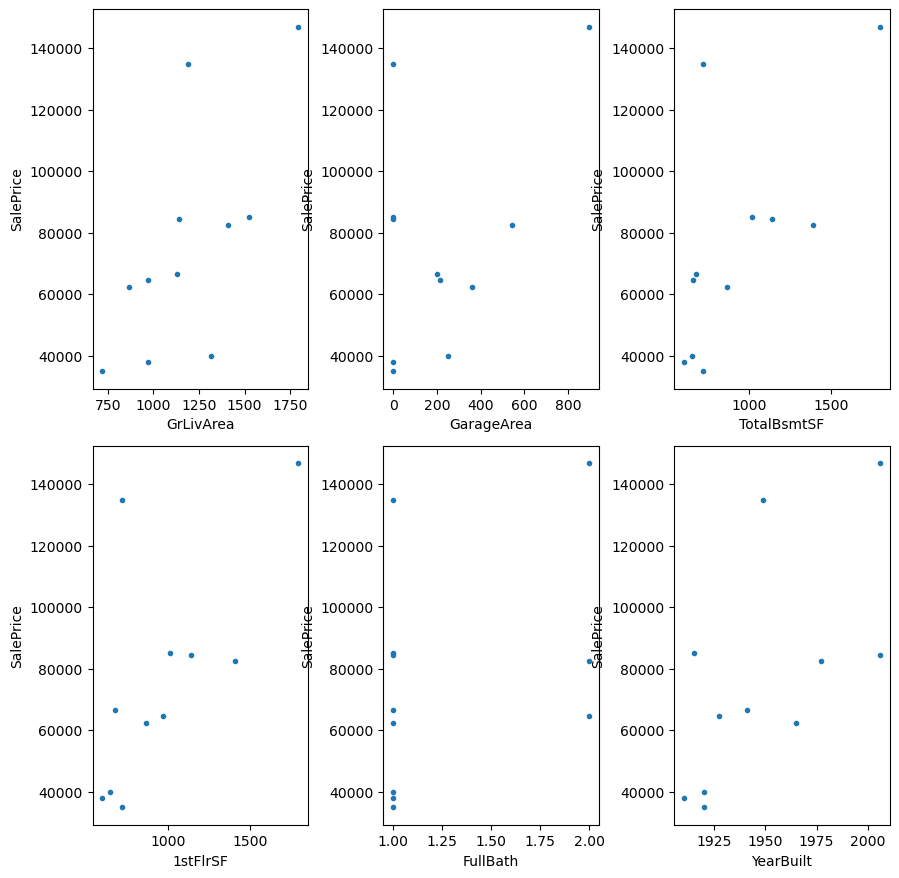

In [383]:

show_target_pairplot(X_rem, ["GrLivArea", "GarageArea", "TotalBsmtSF", "1stFlrSF", "FullBath", "YearBuilt"], TARGET_COL)

# Processing

## Splitting data

In [51]:
def split_data(df, test_size=TEST_PORCENT, target_col=LOGP_TARGET_COL, original_target_col=TARGET_COL, random_state=RANDOM_STATE):
    df_train, df_test = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )
    Y = df_train.pop(target_col)
    Y_orig = df_train.pop(original_target_col)

    X = df_train
    Y_test = df_test.pop(target_col)
    X_test = df_test.drop(columns=original_target_col)

    return X, Y, Y_orig, X_test, Y_test

def split_train_test_data():
  return g_X.copy(), g_Y.copy(), g_Y_orig.copy(), g_X_test.copy(), g_Y_test.copy()

# Using original data to avoid leaking
df_base_data = df_raw_data.copy()
# Transforming Target column
df_base_data[LOGP_TARGET_COL] = np.log1p(df_base_data[TARGET_COL])

# Removing GrLivArea outilers

glArea = 4000
print(f"Removing GrLivArea > {glArea}")
df_base_data = df_base_data[df_base_data["GrLivArea"] < glArea]
df_base_data = fix_invalid(df_base_data)

# Removing SalePrice column and creating Splits
#df_base_data = df_base_data.drop(columns=[TARGET_COL], errors="raise")
g_X, g_Y, g_Y_orig, g_X_test, g_Y_test = split_data(df_base_data, test_size=TEST_PORCENT, random_state=RANDOM_STATE)



Removing GrLivArea > 4000


In [52]:

dfi = df_base_data.copy()
col = "BldgType"
dfi[~dfi[col].isin(CLASS_COLS_VALUES[col])][col]
dfi[dfi[col] == "Duplx"][col]
#df_base_data["Exterior2nd"].value_counts()
#df_base_data["BldgType"].isnull().sum()

# Low cols: ['BldgType', 'Exterior2nd']
# Categories for col BldgType : ['1Fam', '2FmCon', 'Duplx', 'TwnhsE', 'TwnhsI']
# Categories for col Exterior2nd : ['AsbShng', 'AsphShn', 'BrkComm', 'BrkFace', 'CBlock', 'CemntBd', 'HdBoard', 'ImStucc', 'MetalSd', 'Other', 'Plywood', 'PreCast', 'Stone', 'Stucco', 'VinylSd', 'Wd Sdng', 'WdShing']

17      Duplx
39      Duplx
52      Duplx
78      Duplx
102     Duplx
137     Duplx
144     Duplx
188     Duplx
330     Duplx
342     Duplx
420     Duplx
441     Duplx
454     Duplx
505     Duplx
569     Duplx
570     Duplx
582     Duplx
634     Duplx
728     Duplx
736     Duplx
738     Duplx
778     Duplx
779     Duplx
843     Duplx
886     Duplx
894     Duplx
897     Duplx
910     Duplx
913     Duplx
921     Duplx
940     Duplx
942     Duplx
943     Duplx
954     Duplx
955     Duplx
984     Duplx
1003    Duplx
1011    Duplx
1090    Duplx
1129    Duplx
1163    Duplx
1216    Duplx
1230    Duplx
1231    Duplx
1232    Duplx
1275    Duplx
1283    Duplx
1336    Duplx
1350    Duplx
1391    Duplx
1412    Duplx
1450    Duplx
Name: BldgType, dtype: str

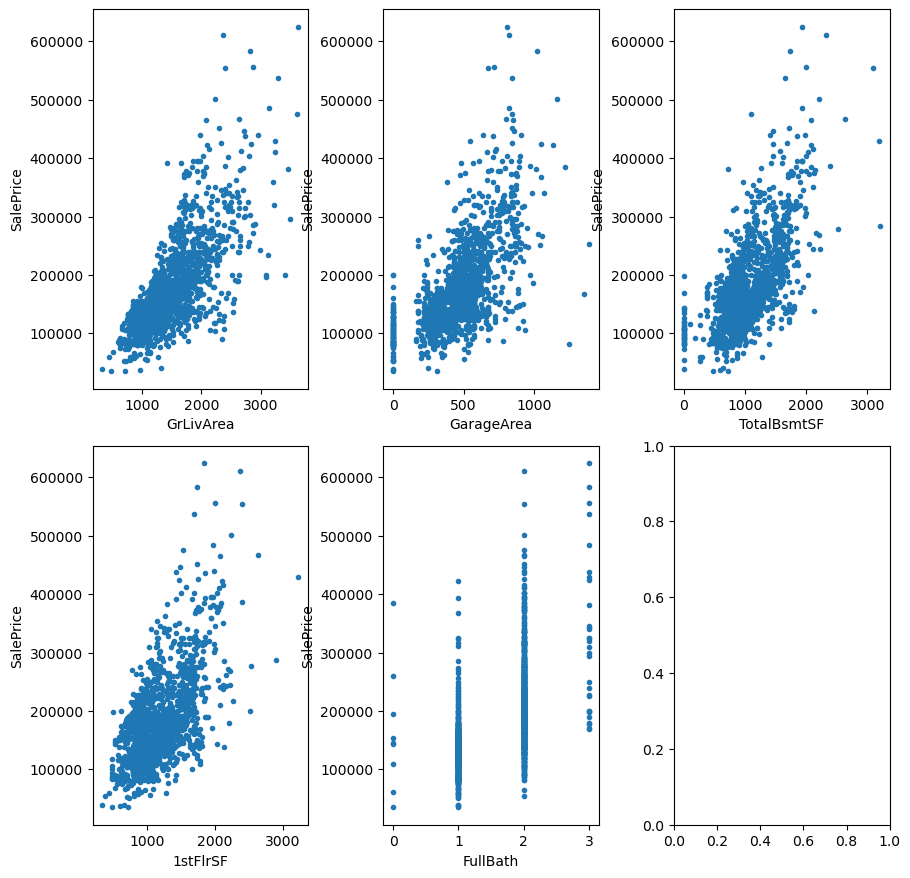

In [53]:

show_target_pairplot(df_base_data, ["GrLivArea", "GarageArea", "TotalBsmtSF", "1stFlrSF", "FullBath"], TARGET_COL)
#df_base_data[df_base_data["GrLivArea"] > 4000][["GrLivArea", TARGET_COL]]

In [54]:
X, Y, Y_orig, X_test, Y_test = split_train_test_data()

Y_test.head()

511    12.219315
963    12.384223
231    12.906694
688    12.879020
34     12.533580
Name: SalePrice_log1p, dtype: float64

## Nulls, Invalid and uncommon data transformation

In [188]:
class FixNullsTransformation(BaseEstimator, TransformerMixin):
  def __init__(self, debug=False):
    self.X_train = None
    self.debug = debug

  def fit(self, X, y=None):
    self.X_train = X
    return self

  def transform(self, X, y=None):
    return fix_nulls(X, self.X_train, debug=self.debug)

class FixInvalidTransformation(BaseEstimator, TransformerMixin):
  def __init__(self, debug=False):
    self.X_train = None
    self.debug = debug

  def fit(self, X, y=None):
    self.X_train = X
    return self

  def transform(self, X, y=None):
    return fix_invalid(X)

class ReplaceUncommonTransformation(BaseEstimator, TransformerMixin):
  def __init__(self, debug=False):
    self.X_train = None
    self.debug = debug

  def fit(self, X, y=None):
    self.X_train = X
    return self

  def transform(self, X, y=None):
    return replace_uncommon(X)




## Drop and Binary Transformation

In [183]:
"""
 DropTransformation
"""
class DropTransformation(BaseEstimator, TransformerMixin):

  def __init__(self, columns):
    self.columns = columns

  def fit(self, X, y=None):
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    # Removing unused columns
    X = X.drop(labels=self.columns, axis=1, errors='ignore')
    return X

"""
Binary transformer
"""
class BinaryTransformation(BaseEstimator, TransformerMixin):
  def __init__(self, bin_cols, bin_spec):
    self.bin_cols = bin_cols
    self.bin_spec= bin_spec

  def fit(self, X, y=None):
    self.fitted_ = True
    return self

  def transform(self, X):
    X = X.copy()
    # Adding binary fields
    drop_cols = []
    for c in self.bin_cols:
      spec = self.bin_spec.get(c, {"drop": False, "true_val": 1})
      X[f"Has{c}"] = X[c].apply(lambda x: 1 if x == spec["true_val"] else 0) 
      if spec["drop"]:
        drop_cols.append(c)
    X = X.drop(columns=drop_cols, errors="raise")
    return X

"""
 Create groups using target encoder
"""
def get_groups(X, y, column):
  enc = ce.TargetEncoder(cols=[column], smoothing=10).fit(X[column], y)
  return enc.transform(X[[column]]).values.flatten()

## Categories

### Enconding Functions

In [56]:
def ordinal_encode(df_X, ord_cat_maps):
    """
    Ordinally encodes specified columns in a DataFrame using provided category-to-integer mappings.
    
    Args:
        df (pd.DataFrame): DataFrame containing columns to encode.
        ord_cat_maps (dict): Dictionary mapping column names to their category-to-integer mappings.
    
    Returns:
        pd.DataFrame: DataFrame with ordinally encoded columns, prefixed with 'enc_'.
    """ 
    df_new = pd.DataFrame()
    cols = df_X.columns
    for col in cols:
        if col in ord_cat_maps:
            df_new["enc_" + col] = df_X[col].apply(lambda x: my_map(x, col, ord_cat_maps))

    return df_new

def my_map(x, col, ord_cat_maps):
    values = ord_cat_maps.get(col, -1)
    val = values.get(x, -1)  # Default to -1 if x is not in the mapping
    if pd.isna(x):
        val = -1
    return val



In [57]:

def classify_columns(df, k=MAX_OHE_CARDINALITY):
    """
    Extracts numeric and categorical columns from a DataFrame, and splits categorical columns into low and high cardinality based on a threshold k.

    Args:
        df (pd.DataFrame): Input dataframe.
        k (int): Threshold for maximum unique values to consider a column low cardinality.

    Returns:
        num_cols (Index): Numeric columns.
        low_cardi (Index): Categorical columns with fewer than k unique values.
        high_cardi (Index): Categorical columns with k or more unique values.
    """
    # Not including category type because the data is loaded from a csv and 
    # the columns are not set to category type by default.
    cat_cols = df.select_dtypes(include=["str"]).columns
    num_cols = df.select_dtypes(include=[np.number]).columns

    low_cardi = [col for col in cat_cols if df[col].nunique() < k] 
    high_cardi = [col for col in cat_cols if df[col].nunique() >= k]
    return num_cols, low_cardi, high_cardi


def get_cat_cols_df(df, ord_cols):
  df = df.copy().drop(columns=ord_cols, errors="ignore")
  return classify_columns(df, k=MAX_OHE_CARDINALITY)

def get_groups(X, y, column):
  enc = ce.TargetEncoder(cols=[column], smoothing=10).fit(X[column], y)
  return enc.transform(X[[column]]).values.flatten()


### Category Transformation

In [58]:
"""
 CategoryTransformation
"""
class CategoryTransformation(BaseEstimator, TransformerMixin):

  def __init__(self, ignored_cols, ord_cols=ORD_COLS, ord_cat_maps=ORD_COLS_VALUES, class_cat_maps=CLASS_COLS_VALUES):
    self.ord_cols = ord_cols
    self.ord_cat_maps = ord_cat_maps
    self.ignored_cols = ignored_cols
    self.target_encoder = None
    self.one_hot_encoder = None
    self.low_nom_cols = None
    self.high_nom_cols = None
    self.num_cols = None
    self.class_cat_maps = class_cat_maps

  def fit(self, X, y=None):
    # Removing ignored columns
    X = X.drop(columns=self.ignored_cols)
    # Selecting Categorical columns from low cardinality categories
    df_ord = X[self.ord_cols]
    df_data_no_ord = X.drop(labels=self.ord_cols, axis=1)

    # Extracting numeric and categorical columns with low and high cardinality
    num_cols, low_cols, hi_cols = classify_columns(df_data_no_ord, k=MAX_OHE_CARDINALITY)
    subClassCol = "MSSubClass"
    low_cols.append(subClassCol)
    num_cols = [x for x in num_cols if x != subClassCol]

    self.target_encoder = ce.TargetEncoder(cols=hi_cols, smoothing=10).fit(X[hi_cols], y)

    class_categories = [self.class_cat_maps[col] for col in low_cols]
    # cin = [x for i, x in enumerate(low_cols) if i in [9, 14]]
    # print("Low cols:", cin) 
    # for col in cin:
    #    print("Categories for col", col, ":", class_categories[low_cols.index(col)])

    self.one_hot_encoder = OneHotEncoder(categories=class_categories, sparse_output=False, drop="first", handle_unknown="infrequent_if_exist").fit(X[low_cols])

    self.num_cols = num_cols
    self.low_nom_cols = low_cols
    self.high_nom_cols = hi_cols
    self.fitted_ = True
    return self


  def transform(self, X):
    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    #print("low nom categories:", self.low_nom_cols)
    # One-hot encoding low cardinality categorical columns
    ohe_feature_names = self.one_hot_encoder.get_feature_names_out(self.low_nom_cols)
    df_low_nominal = pd.DataFrame(self.one_hot_encoder.transform(X[self.low_nom_cols]), columns=ohe_feature_names, index=X.index)
    df_ord = ordinal_encode(X[self.ord_cols], self.ord_cat_maps)
    df_target_encoded = self.target_encoder.transform(X[self.high_nom_cols])
    ohe_feature_names = self.one_hot_encoder.get_feature_names_out(self.low_nom_cols)

    X = pd.concat([X[self.num_cols], df_ord, df_low_nominal, df_target_encoded], axis=1)

    return X




## Scalers and Distribution Transformation


In [184]:
"""
Log1P transformer
"""
class Log1PTransformation(BaseEstimator, TransformerMixin):
  """
  Applies log1p transformation to specified columns.
  """
  def __init__(self, columns):
    self.columns = columns

  def fit(self, X, y=None):
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    X[self.columns] = np.log1p(X[self.columns])
    return X

"""
Sqrt transformer
"""
class SqrtTransformation(BaseEstimator, TransformerMixin):
  """
  Applies sqrt transformation to specified columns.
  """
  def __init__(self, columns):
    self.columns = columns

  def fit(self, X, y=None):
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    X[self.columns] = np.sqrt(X[self.columns])
    return X



"""
Standard Scaler
"""
class StandardScalerTransformation(BaseEstimator, TransformerMixin):
  """
  Applies standard normalization to specified columns.
  """
  def __init__(self, columns):
    self.columns = columns
    self.scaler = StandardScaler()

  def fit(self, X, y=None):
    self.scaler.fit(X[self.columns])
    self.fitted_ = True
    return self

  def transform(self, X, y=None):
    # Copying data to avoid modifying the original DataFrame by mistake
    X = X.copy()
    x_index = X.index
    norm = self.scaler.transform(X[self.columns])
    df_norm = pd.DataFrame(norm, columns=self.columns, index=x_index)
    X[self.columns] = df_norm
    return X


In [60]:
# norm_cols = ['YearBuilt', 'YearRemodAdd','MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF', 'LowQualFinSF', 'WoodDeckSF', 'OpenPorchSF', 'PoolArea']
# tdf = df_base_data.copy()[norm_cols]
# tdf.head()
# sc = StandardScalerTransformation(norm_cols)
# sc.fit(tdf)
# tran = sc.transform(tdf)
# tran.head()

# Experiment

## Baseline

In [66]:
# For baseline, category columns will be enconded without any transformation or processing to get an initial idea of performance 

run_label = "baseline"

X, Y, _, X_test, Y_test = split_train_test_data()

pipeline =  Pipeline([
  ("init_drop", DropTransformation(columns=[LOGP_TARGET_COL, TARGET_COL, "Id"])),
  ("fix_nulls", FixNullsTransformation()),
  ("encode", CategoryTransformation(ignored_cols=[], ord_cols=ORD_COLS, ord_cat_maps=ORD_COLS_VALUES)),
])

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

groups = get_groups(X, Y, column="Neighborhood")
desc = "Basic category enconding. No data transformation. No feature engineering\n"
if groups is not None:
  desc+= "Using groups"

eval_models(X, Y, X_test, Y_test, pipeline, label=run_label, clear_scores=False, desc=desc, show_cv_error=True, pred_test=True, groups=groups)

#show_global_scores()
#plot_scores()
show_scores_stats(show_test=True)

Train dataset shape: (1164, 80)
Test dataset shape: (292, 80)
Saving score in memory
Saving score in memory
Saving score in memory
Saving score in memory
Saving score in memory
------------------------------
Last Run: 3 - baseline
------------------------------
Model: LiRe CV_MEAN: 0.1620 (0.0182), TRN_RMSE: 0.0971 TST_RMSE: 0.1110
Model: Lasso CV_MEAN: 0.1878 (0.0270), TRN_RMSE: 0.1696 TST_RMSE: 0.1566
Model: ENet CV_MEAN: 0.1379 (0.0210), TRN_RMSE: 0.1085 TST_RMSE: 0.1015
Model: Rig CV_MEAN: 0.1449 (0.0196), TRN_RMSE: 0.0993 TST_RMSE: 0.1034
Model: XBReg CV_MEAN: 0.1495 (0.0181), TRN_RMSE: 0.0740 TST_RMSE: 0.1073
Description: Basic category enconding. No data transformation. No feature engineering
Using groups
------------------------------
Top 5 (CV)
------------------------------
normalization(2) - ENet --> CV_MEAN: 0.1173, 0.0069, delta: nan 
normalization(2) - Rig --> CV_MEAN: 0.1197, 0.0073, delta: 0.0024 
normalization(2) - LiRe --> CV_MEAN: 0.1257, 0.0070, delta: 0.0059 
norma

## Engineering

### Functions

In [62]:
### Functions
class DescriptionBuilder:
  """
  A class to build a description string for the data processing steps.

  Attributes:
    desc (str): The description string.
  """

  def __init__(self):
    self.desc = ""

  def append(self, text):
    self.desc += text + "\n"
    return self

  def get(self):
    return self.desc

def drop_cols(X, X_test, cols):
  X = X.drop(labels=cols, axis=1, errors="raise")
  X_test = X_test.drop(labels=cols, axis=1, errors="raise")
  return X, X_test

def get_ord_cols(by="used", used=[], removed=[], ord_cols=ORD_COLS):
  return get_cols(by=by, used=used, removed=removed, all_cols=ord_cols)

def get_nom_cat_cols(by="used", used=[], removed=[], cat_cols=[]):
  return get_cols(by=by, used=used, removed=removed, all_cols=cat_cols)

def get_cols(by="used", used=[], removed=[], all_cols=[]):
  cols_to_remove = removed.copy()
  cols_to_use = used.copy()
  if by == "used":
    cols_to_remove = [x for x in all_cols if x not in used]
  elif by == "removed":
    cols_to_use = [x for x in all_cols if x not in removed]
  else:
    raise ValueError("by must be 'used' or 'removed'")

  return cols_to_use, cols_to_remove

### Process Description


**05/02/26**
- Adding PoolQC the score goes up. => it's a noisy feature that has to be removed. Adding HasPool Feat doesn't change the score. Perhaps PoolArea is enough for pool information.
- Removing all ordinals cols and adding HasPool doesn't have impact in CV
- By removing all ordinal categories the score has reduced more than 0.01. Let's play with them to see if we can improve the score by adding one by one, with or without transformatios.

**06/02/26**
- Adding only LandSlope the score goes up to 0.1412
- After fixing some issue in **encode_categories** function, removing all ordinal columns is now a little bit worse than baseline (0.1408). Starting again analisis.
- Baseline is 0.1400

**07/02/26**
- For now will leave categories using HeatingQC, ExterQual and ExternCond and continue playing with other aspects 
- ExterCond is unbalanced. Created a 1/0 feature and doesn't improve performance. There was only one row having value="Po" and it was removed. Performance is a little worse than using the field as it is.
- ExterQual is unbalanced but it does not have a clear way to collapse categories that improves performance. Leaving as it is.
- For HeatingHQ, there is one only value ="Po". Also, there are no values in test set. The row was removed and the performance continuous equal.
- Adding HeatingHC, ExterQual, ExternCond without transformations to ordinal cols used and removing all others improved performnance.
- Running all ordinal categories without any transformation one at a time  results in only HeatingHC, ExterQual, ExternCond performing better than baseline.

**14/02/26**
- Removing all non ordinal categories results in a degradation in the score. So, there is some signal lost there.
- By running using one non ordinal category features at a time, and using the ones that degrade the performance less, the score improves. These features are not the same than the list created ordering by MI. 
- MSZoning has a lot of signal.
- Removing all extreme imbalanced categories degrades the score.

**16/02/26**
- Using IQR in log1p SalePrice doesn't remove rows. 
- Applying winsorization doesn't improve the score. (Tryied with 0.95 and 0.99 quantiles)
- Capping SalePrice > 700000 and 600000 makes the performance decrease
- Capping SalePrice > 500000 makes the performance slightly better. But it is still better using IQR (SalePrice).
- Removing rows by using IQR on SalePrice improved the score a bit. Maintaining for now, but a lot of rows are removed.
- Removing GarageCars == 4 and changing it to 3 improves the score a little bit, but removed anyway to fit the general trend.
- Removing GrLivArea > 4000 and SalePrice < 200000 improves the score.
- Outliers

**19/02/26**
- Creating binary fields for columns having a lot of zero values doesn't improve the performance.

**20/02/26**
- Creating new fields improve performance in TreeModels and mostly XBRegressor. Simple linear regression has also improved a bit.

**23/02/26**
- Dividing residuals in 5 quantiles we can confirm that:
    - (12.301, 12.746]    0.063642
    - (12.082, 12.301]    0.060717
    - (11.894, 12.082]    0.057325
    - (11.714, 11.894]    0.064025
    - (10.632, 11.714]    0.093581
- Plotting residuals for Ridge, it shows that resituals are bigger for low prices.

**24/02/26**
- Start modeling. Tunning ridge, learning rate depends on data processing. There is no much improvement, it seems that weights are stable.

**26/02/26**
- Creating pipeline to apply to CV to fix leakage. 
- While adding an interaction term between "Neighborhood" and other fields, a leakage was found. Fixing will make CV score increase.

**03/03/26**
- Spend some time fixing leakage when cv. Improved process by using transformers and pipeline components.

**04/03/26**
- Start modeling
- Applyied log1p trasformation to some skewed features. Performance was improved.

**11/03/26**
- Predicting on test set get very bad results.
- Getting the best result using ElasticNet.
- Used and tuned Elastic Net and XGBRegressor. XGBRegressor is still overfiting. Maybe because of small dataset

**16/03/26**
- There was an issue initially while removing outliers on the whole dataset. After that the test performance got better.
- Investigating about poor performance in Test set.

**17/03/26**
- After the submission, I will  continue doing some feature selection with Lasso, some coeficient analysis and a deeper XGBoost parameter tuning.
- Having a achieving a fair performance in CV and test set an initial submition will be done in order to know how well the model is performing compared with other scripts.

**20/03/26**
- First submission (sad 0.18882 - rank: 3593)

**30/03/26**
- Still pending using Lasso for feature selection, tune XGBost and Stacking
- Improved Log1p and sqrt over eng features.
- CV goes up locally because some some data fixed in training and test set. 
- Second submission (0.13227 - rank: 1671). Still sad.

**01/04/26**
- Second submission (0.13096 - rank: 1572). Realizing that previous submission were done using only X_train to train data. Fixing that by using the whole dataset. 
- Third submission (0.13068 - rank: 1547). Removing test rows with GrLivArea > 4000

**06/04/26**
- 4th submission( 0.12711 - rank: 1132). Stacking LinearRegression, ElasticNet, XGBRegressor and Ridge as final estimator. Using tuned parameter independently.
- 5th submission (0.12909). Uncommenting interquartile outliers removal improves cv but degrades performance in kaggle.
- 6th submission (0.12705 - rank: 1113). Replacing uncommon values in test set (added to pipeline). 

**08/04/26**
- 7th submission (0.12605 - rank: 1005). Analizing Ridget residuals and removed all > abs(0.4) from X set.

### Run

In [384]:
## Splitting data

X, Y, Y_orig, X_test, Y_test = split_train_test_data()

X = X[~X.index.isin(bigres_idx)]
Y = Y[~Y.index.isin(bigres_idx)]

def initial_processing(X, Y, Y_orig):
  desc = DescriptionBuilder()
  run_label = "after_pipeline_impl"


  # Getting feature classification
  num_cols, low_cardi, high_cardi = get_cat_cols_df(X, ORD_COLS)
  nominal_cat_cols = low_cardi + high_cardi

  # Best Score class categories
  nominal_cat_cols_used = ["Neighborhood", "MSZoning", "Functional", "Condition2", 'SaleCondition', 'Exterior1st', 'GarageType',
                           'MasVnrType', 'PavedDrive', 'LotConfig', 'Alley', 'LotShape', 'SaleType', "MiscFeature", "RoofMatl", 'Fence',
                           'Condition1', 'BldgType', 'GarageFinish', 'Foundation'] # Street, and Utilities removed (almost constant)

  # Features ordered from best performance to worst when running one by one
  # ['Neighborhood', 'Functional', 'CentralAir', 'Condition2', 'SaleCondition', 'Street', 'Exterior1st', 'GarageType',
  # 'MasVnrType', 'PavedDrive', 'LotConfig', 'Alley', 'LotShape', 'SaleType', 'MiscFeature', 'RoofMatl', 'Fence', 'Utilities',
  # 'Condition1', 'BldgType', 'GarageFinish', 'Foundation', 'Heating', 'HouseStyle', 'LandContour', 'Electrical', 'RoofStyle', 'Exterior2nd']

  # Getting class categories to removed from train data
  _ , nominal_cat_cols_to_drop = get_nom_cat_cols(by="used", used=nominal_cat_cols_used, removed=[], cat_cols=nominal_cat_cols)

  # There is only one row with HeatingQC=Po, so removing it to avoid statistical issues
  X = X[~X.index.isin([325, 250])]
  Y = Y[~Y.index.isin([325, 250])]

  # Adding to description
  desc.append("Removing the only row having HeatingQC=Po and ExterCond=Po")

  """
    Processing ordinal columns 
  """
  ord_cols_used = ["ExterQual", "HeatingQC", "ExterCond", "GarageQual"]
  ord_cols_to_drop = [] 
  ord_cols_used, ord_cols_to_drop = get_ord_cols(by="used", used=ord_cols_used, removed=ord_cols_to_drop, ord_cols=ORD_COLS)

  """
   Removing not used class and oridinal features 
  """
  ignored_cols = nominal_cat_cols_to_drop + ord_cols_to_drop
  # 3SsnPorch is almost constant and there is no signal in relation with the target
  ignored_cols.append("3SsnPorch") 
  ignored_cols  += ['ScreenPorch', 'MiscVal', 'KitchenAbvGr', 'EnclosedPorch']

# ScreenPorch, MiscVal, LowQualFinSF, KitchenAbvGr, 3ssnPorch, LowQualFinSF, EnclosedPorch, BsmtFinSF2, BsmtFullBath and BsmtHalfBath are almost constant. Check removal 
# LotArea, LotFrontage, OpenPorchSF, WoodDeckSF, TotalBsmtSF heavy right skewed. -> Log1p?
# PoolArea, OpenPorchSF, WoodDeckSF mostly 0. Add binary
# YearBuilt is left skewed... Transformation?
# What to do with YearRemodAdd?

  """
    run_label: Groups several experiments related to an aspect (categories, outliers, new features, etc) to then identify the best score obtained
  """
  run_label = "proc_outliers"

  # Description of the current experiment
  desc.append("- Processing categories. Merging values and creating 1/0 features")
  desc.append(f"- Using Ordinal categories => {ord_cols_used}.")
  desc.append(f"- Using NO ordinal categories => {nominal_cat_cols_used}")
  desc.append("- Removed Street and Utilities features because they are almost constant")



  # Removing outliers using IQR on SalePrice
  # _, dfrem = remove_outliers(X.copy().join(Y_orig), ["SalePrice"])
  # X = X[~X.index.isin(dfrem.index)]
  # Y = Y[~Y.index.isin(dfrem.index)]
  # Y_orig = Y_orig[~Y_orig.index.isin(dfrem.index)]
  # This step degrades performance in Kaggle (But improves CV)

  """
   Outliers description
  """
  desc.append("- Removed hight 'GrLivArea' and low SalePrice outilers. ")
  desc.append("- Replacing GarageCargs = 4 by 3")
  desc.append("- Replacing Fireplaces = 3 by 2")
  desc.append("- Fixing FullBath = 0. Replaced by 1")
  desc.append("- Removig outliers using IQR (Log1p SalePrice)")
  #desc.append("- ")

  return X, Y, Y_orig, ignored_cols, ord_cols_used, desc

"""
##############################################################################
 Experiment
##############################################################################
"""

X, Y, Y_orig, ignored_cols, ord_cols_used, desc = initial_processing(X, Y, Y_orig)





"""
 Feature Engineering
"""
#run_label = "feat_engineering_combination"
# eng_cols = ["TotalSF", "TotalSFTimesOverallQual", "GarageAreaTimesQual", "HouseAge", "BathGrLivArea", "BathBsmt", "Bath", \
#            "GrLivAreaOverRoom", "GrLivAreaOverBedroom", "GrLivAreaOverBath", "TotalBsmtSFOverBath", "GarageAreaOverCar", \
#             "NeighborhoodOverLotArea", "NeighborhoodTimesLotArea",  "TotalSFTimesOverallCond"
           #]
# Adding prefix
#eng_cols = [f"eng_{col}" for col in eng_cols]


def create_eng_features(X):
    X = X.copy()
    X["eng_TotalSF"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"] + X["GarageArea"] + X["PoolArea"]
    X["eng_TotalSFTimesOverallQual"] =  X["eng_TotalSF"] * X["OverallQual"]
    X["eng_TotalSFTimesOverallCond"] =  X["eng_TotalSF"] * X["OverallCond"]
    X["eng_GarageAreaTimesQual"] = X["GarageArea"] * X["enc_GarageQual"]
    X["eng_HouseAge"] = this_year() - X["YearBuilt"]
    X["eng_BathGrLivArea"] = X["FullBath"] + X["HalfBath"]
    X["eng_BathBsmt"] = X["BsmtFullBath"] + X["BsmtHalfBath"]
    X["eng_Bath"] = X["FullBath"] + X["HalfBath"] +  X["BsmtFullBath"] + X["BsmtHalfBath"]
    X["eng_GrLivAreaOverRoom"] = X["GrLivArea"] / (X["TotRmsAbvGrd"] + 1)
    X["eng_GrLivAreaOverBedroom"] = X["GrLivArea"] / (X["BedroomAbvGr"] + 1)
    X["eng_GrLivAreaOverBath"] =  X["GrLivArea"] / (X["eng_BathGrLivArea"] + 1)
    X["eng_TotalBsmtSFOverBath"] =  X["TotalBsmtSF"] / (X["eng_BathBsmt"] + 1)
    X["eng_GarageAreaOverCar"] = X["GarageArea"] / (X["GarageCars"] + 1)
    X["eng_NeighborhoodOverLotArea"] = X["Neighborhood"] / (X["LotArea"] + 1)
    X["eng_NeighborhoodTimesLotArea"] = X["Neighborhood"] * X["LotArea"]
    return X




class EngTransformation(BaseEstimator, TransformerMixin):

  def __init__(self, transf):
    self.transf = transf

  def fit(self, X, y):
    self.fitted_ = True
    return self

  def transform(self, X):
    return self.transf(X)


#desc.append(f"- Added combination columns: {eng_cols} ")

"""
  Feature transformation 
"""
# Applying Log1p transformation to most important and skewed features
log1p_cols = ["GarageArea", "GrLivArea", "LotArea", "LotFrontage", "1stFlrSF", "PoolArea", "OpenPorchSF", "WoodDeckSF"]


# Transformer is created on pipeline creationg
desc.append(f"- Applying log1p transformation to: {log1p_cols}")

"""
  Log1p and sqrt transformation to some of the engineered features
"""
eng_log1p_cols = ["eng_HouseAge", "eng_NeighborhoodTimesLotArea", "eng_NeighborhoodOverLotArea"]
log1p_cols+=eng_log1p_cols
sqrt_cols = ["eng_TotalSF", "eng_TotalSFTimesOverallQual", "eng_TotalSFTimesOverallCond", "eng_GrLivAreaOverRoom", "eng_GrLivAreaOverBath"]
desc.append(f"- Adding log1p transformation for eng cols: {eng_log1p_cols}")
desc.append(f"- Adding Sqrt transformation  for eng cols: {sqrt_cols}")
"""
 Binary Transformation
"""
bin_cols = ["GarageArea", "TotalBsmtSF", "2ndFlrSF", "PoolArea", "CentralAir"]
bin_cols_spec = {"CentralAir": {"drop": True, "true_val": "Y"}}


desc.append(f"- Adding binaary fields: {bin_cols}")
#desc.append("")

"""
 Transformations description
"""
desc.append("- Fixed Fireplaces and fullbath.")
desc.append("- FROM RUN_ID = 141 Using KFolds to validate. ==> Score goes UP")
desc.append("- XGBRegressor V2 params")

"""
 Transformations Normalization
"""
# Normalize some continue features to optimize training
run_label = "normalization"
norm_cols = ['YearBuilt', 'YearRemodAdd','MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF', 'LowQualFinSF', 'WoodDeckSF', 'OpenPorchSF', 'PoolArea']
# Transformer is created on pipeline creationg
desc.append("- Getting ConvergenceWarnings during training and modeling. So applied standard normalization to optimize fitting process.")


xgb_less_imp = ["LowQualFinSF","MasVnrArea","LotShape_IR1","MSZoning_RM","enc_GarageQual","MSZoning_RL","GarageCars","HalfBath",
                "MSSubClass_30","Exterior1st_MetalSd","Condition1_Norm","Functional_Maj1",
                "enc_ExterQual","enc_ExterCond","RoofMatl_Tar&Grv","Exterior1st_VinylSd","GarageFinish_Unf","GarageType_CarPort","MasVnrType_BrkFace",
                #"Condition1_PosN","BldgType_Duplx","Condition2_Norm", "MSSubClass_80","MSSubClass_160",
               ]

"""
 Pipeline creation
"""
def create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, eng_transf, model=None):
  steps = [
    ("init_drop", DropTransformation(columns=[LOGP_TARGET_COL, TARGET_COL, "Id"])),
    ("fix_nulls", FixNullsTransformation()),
    ("fix_invalid", FixInvalidTransformation()),
    ("replace_uncommon", ReplaceUncommonTransformation()),
    ("binary", BinaryTransformation(bin_cols, bin_cols_spec)),
    ("drop", DropTransformation(columns=ignored_cols)),
    ("encode", CategoryTransformation(ignored_cols=[], ord_cols=ord_cols_used, ord_cat_maps=ORD_COLS_VALUES)),
    ("eng_features", EngTransformation(eng_transf)),
    ("log1p", Log1PTransformation(columns=log1p_cols)),
    ("sqrt", SqrtTransformation(columns=sqrt_cols)),
    ("std_scaler", StandardScalerTransformation(norm_cols)),
    #("xgb_less_imp", DropTransformation(columns=xgb_less_imp)),
  ]
  if model is not None:
    steps.append(("model", model))
  return Pipeline(steps)


# ignored_cols = []



# ord_cols_used = ORD_COLS
pipeline = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features)

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)



#groups = get_groups(X, Y, "Neighborhood")
groups = None
eval_models(X, Y, X_test, Y_test, pipeline, label=run_label, clear_scores=False, desc=desc.get(), show_cv_error=True, show_coef=False, pred_test=True, rep_kfold=False, groups=groups)

show_scores_stats(show_test=True)










Train dataset shape: (1151, 80)
Test dataset shape: (292, 80)


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### Debug


In [64]:
show_scores_stats(run_id=1)

------------------------------
Last Run: 1 - baseline
------------------------------
Model: LiRe CV_MEAN: 0.1407 (0.0084), TRN_RMSE: 0.0971
Model: Lasso CV_MEAN: 0.1740 (0.0099), TRN_RMSE: 0.1696
Model: ENet CV_MEAN: 0.1227 (0.0065), TRN_RMSE: 0.1022
Model: Rig CV_MEAN: 0.1255 (0.0076), TRN_RMSE: 0.1000
Model: XBReg CV_MEAN: 0.1235 (0.0070), TRN_RMSE: 0.0736
Description: Basic category enconding. No data transformation. No feature engineering
------------------------------
Top 5 (CV)
------------------------------
normalization(2) - ENet --> CV_MEAN: 0.1138, 0.0143, delta: nan 
normalization(2) - Rig --> CV_MEAN: 0.1149, 0.0145, delta: 0.0011 
normalization(3) - ENet --> CV_MEAN: 0.1173, 0.0072, delta: 0.0024 
normalization(2) - LiRe --> CV_MEAN: 0.1188, 0.0125, delta: 0.0015 
normalization(3) - Rig --> CV_MEAN: 0.1191, 0.0077, delta: 0.0003 
                              
------------------------------
------------------------------
Top 5 (TEST)
------------------------------
normaliz

In [ ]:



steps = pipeline.steps[:-1]
pip = Pipeline(steps=steps)
tx = pip.fit_transform(X, Y)

# tx[tx.isnull()][norm_cols].head()

tx[norm_cols].isnull().sum()
# print("TX", tx.shape)

# X.shape




# Modeling

## Ridge

In [281]:

X, Y, Y_orig, X_test, Y_test = split_train_test_data()
X, Y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, Y, Y_orig)

cv = KFold(
      n_splits=5,
      shuffle=True,
      random_state=RANDOM_STATE
    )
alphas = np.logspace(-2, 6, 100)
model = Ridge()

pipeline = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features, model=model)
grid = GridSearchCV(
  pipeline,
  {"model__alpha": alphas },
  cv=cv,
  scoring="neg_root_mean_squared_error",
  n_jobs=-1
)
grid.fit(X, Y)

print("Best alpha:", grid.best_params_)
print("Best CV:", -grid.best_score_)

Best alpha: {'model__alpha': np.float64(5.590810182512229)}
Best CV: 0.11757352942714269


## XGBRegressor

In [118]:
def xgb_cv(X, y, cv, model_params):

  scores = []
  best_iterations = []

  for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=TEST_PORCENT, random_state=RANDOM_STATE)

    model = XGBRegressor(**model_params)
    preproc_pip = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features)
    X_train_trans = preproc_pip.fit_transform(X_train, y_train)
    X_val_trans = preproc_pip.transform(X_val)
    X_test_trans = preproc_pip.transform(X_test)
    model.fit(X_train_trans, y_train, eval_set=[(X_val_trans, y_val)], verbose=False)
    y_pred = model.predict(X_test_trans)

    rmse = root_mean_squared_error(y_test, y_pred)
    scores.append(rmse)
    best_iterations.append(model.best_iteration)
    #print("booster", model.get_booster())
    feat_imp = pd.Series(model.get_booster().get_fscore()).sort_values(ascending=False)

  return {
    "mean_rmse": np.mean(scores),
    "std_rmse": np.std(scores),
    "mean_best_iter": int(np.mean(best_iterations)),
    "median_best_iter": np.median(best_iterations),
    "feat_imp": feat_imp,
  }

### 1st approach

In [ ]:
##################
# Initial
# Score: 1230
# Params
# model = XGBRegressor(
#   max_depth=3,
#   learning_rate=0.05,
#   n_estimators=4000,
#   min_child_weight=3,
#   gamma=0,
#   reg_lambda=20,
#   reg_alpha=0,
#   tree_method="hist",
#   random_state=RANDOM_STATE
# )

# Best scores obteined in Random Search
# Run 1: 0.12227014762004437

X, Y, Y_orig, X_test, Y_test = split_train_test_data()
X, Y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, Y, Y_orig)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rng = np.random.default_rng(RANDOM_STATE)






def sample_params(rng):
  return {
    # "max_depth": int(rng.integers(3,5)),
    "max_depth": int(3),
    "learning_rate": float(rng.choice([0.05,0.06, 0.07])),
    "subsample": float(rng.uniform(0.60, 0.7)),
    "colsample_bytree": float(rng.uniform(0.8, 0.92)),
    "min_child_weight": float(rng.uniform(5, 7)),
    "gamma": float(rng.uniform(0,0.3)),
    "reg_lambda": float(rng.choice([18, 19, 20, 21])),
    "reg_alpha": float(rng.choice([0.09, 0.1, 0.12])),
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_estimators": 8000,
    "tree_method":"hist",
    "random_state": RANDOM_STATE,
    "n_jobs":-1, "early_stopping_rounds": 100
  }

    # Best: 0.11784502838639839
    # {'max_depth': 3, 'learning_rate': 0.06, 'subsample': 0.6485535138779588, 'colsample_bytree': 0.8507154075709737, 'min_child_weight': 6.755057811743592, 'gamma': 0.026044461664468242, 'reg_lambda': 21.0, 'reg_alpha': 0.12, 'objective': 'reg:squarederror'}
    #Best: 0.11822490510191938
    #Best params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.6716750680563728, 'colsample_bytree': 0.8775254028279627, 'min_child_weight': 6.222677368550403, 'gamma': 0.022114929787361258, 'reg_lambda': 20.0, 'reg_alpha': 0.1, 'objective': 'reg:squarederror'}

    #Best: 0.11888564460916543
    #Best params: {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.745803023415262, 'colsample_bytree': 0.985484785724912, 'min_child_weight': 7.903778569773939, 'gamma': 0.014706304965369288, 'reg_lambda': 19.0, 'reg_alpha': 0.07, 'objective': 'reg:squarederror'} 
    # Params Run 2
    # Best: 0.11880496222511969
    # Best params: {'max_depth': 4, 'learning_rate': 0.06, 'subsample': 0.672233910061568, 'colsample_bytree': 0.8954856732816766, 'min_child_weight': 6.14256040410197, 'gamma': 0.0192266479929305, 'reg_lambda': 20.0, 'reg_alpha': 0.1, 'objective': 'reg:squarederror'}
    # return {
    #     "max_depth": int(rng.integers(3,5)),
    #     "learning_rate": float(rng.choice([0.04,0.05,0.06, 0.07])),
    #     "subsample": float(rng.uniform(0.65,0.9)),
    #     "colsample_bytree": float(rng.uniform(0.65,0.9)),
    #     "min_child_weight": float(rng.uniform(1,10)),
    #     "gamma": float(rng.uniform(0,3)),
    #     "reg_lambda": float(rng.choice([15,17,20,22])),
    #     "reg_alpha": float(rng.choice([0, 0.05, 0.07, 0.1, 0.12])),
    #     "objective": "reg:squarederror"
    # }

    #######################

best_score = 999
best_params = None
for i in range(40):
    params = sample_params(rng)
    mean_rmse, std_rmse = xgb_cv(X, Y, cv, params)
    print(i, mean_rmse, std_rmse)
    if mean_rmse < best_score:
        best_score = mean_rmse
        best_params = params
print("Best:", best_score)
print("Best params:", best_params)

# Default params:
# {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 
# 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 
# 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 
# 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 
# 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 
# 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 
# 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None



### 2nd Approach

In [121]:

# Starting point for tuning params based on CV results and feature importance analysis. 
# Using learning_rate = 0.1 and tune tree specific params: max_ddepth, min_child_weight, gamm, subsample, colsample_bytree
# Also applying initial values to tune
# Getting best_iteration = 81, so using n_estimators = 82 to avoid overfitting


rng = np.random.default_rng(RANDOM_STATE)
SEED=27
params_step1 = {
  'learning_rate': 0.1,
  'max_depth': 5,
  'min_child_weight': 1,
  'gamma': 0,
  'subsample': 0.8, 'colsample_bytree': 0.8,
  #"n_estimators": 1000,
  "n_estimators": 82,
  "random_state": RANDOM_STATE,
  "tree_method":"hist",
  "seed":SEED,
  "n_jobs":-1,
  'objective': 'reg:squarederror',
  "early_stopping_rounds": 50,
}

def sample_params_v2(rng=None):
  if rng == None:
    return params_step1

  return {
    "learning_rate": 0.1,
    "n_estimators": 82,
    "max_depth": 3, #rng.choice([2, 3, 5]),
    "min_child_weight": 3.253085737531595, #float(rng.uniform(1, 5)),
    "subsample": 0.5969192662698124, #rng.uniform(0.59, 0.62),
    "colsample_bytree": 0.7320808520425763, #rng.uniform(0.73, 0.77),
    #"gamma": rng.uniform(0.0, 0.015),
    "gamma": 0.012199053588004086,
    "reg_lambda": 1.001187324408089, #rng.uniform(1.0, 1.2),
    "reg_alpha": 6.405920704482397e-10, #rng.uniform(1.e-11, 1.e-9),
    "random_state": RANDOM_STATE,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method":"hist",
    "n_jobs":-1, "early_stopping_rounds": 50,
    "seed": SEED,
  }


params = params_step1.copy()
X, y, y_orig, X_test, y_test = split_train_test_data()
X, y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, y, y_orig)

Xt = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features).fit(X, y).transform(X)
#Choose all predictors except target & IDcols
predictors = [x for x in Xt.columns]

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

#print("Predictors:", predictors)

best_result = {"mean_rmse": 999 }
best_params = None

num_tests = 1
for i in range(num_tests):
    params = sample_params_v2(rng)
    result = xgb_cv(X, y, cv, params)
    if result["mean_rmse"] < best_result["mean_rmse"]:
      print("New Best:", result["mean_rmse"], "i=", i)
      best_result = result
      best_params = params


print("Best:", best_result["mean_rmse"], "std :", best_result["std_rmse"])
print("Best Iter:", best_result["median_best_iter"], "(", best_result["mean_best_iter"], ")")
print("Best Params:", best_params)



#############
# Best: 0.12430462488950784 / Lamda
# Best Iter: 72.0 ( 73 )
# Best Params: {'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': 3, 'min_child_weight': 3.253085737531595, 'subsample': 0.5969192662698124, 'colsample_bytree': 0.7320808520425763, 'gamma': 0.012199053588004086, 'reg_lambda': 1.001187324408089, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}
########
# Best 7: 0.12431569332658472 // Lamda
# Best Iter: 71.0 ( 73 )
# Best Params: {'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': 3, 'min_child_weight': 3.253085737531595, 'subsample': 0.5969192662698124, 'colsample_bytree': 0.7320808520425763, 'gamma': 0.012199053588004086, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}
########
# Best 6: 0.12507882611997187 // subsample, colsample_bytree
# Best Iter: 81.0 ( 77 )
# Best Params: {'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': 3, 'min_child_weight': 3.253085737531595, 'subsample': 0.6120213452015378, 'colsample_bytree': 0.7495096505235324, 'gamma': 0.012199053588004086, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}
########
# Best: 5: 0.12549096344006433 // subsample, colsample_bytree
# Best Iter: 78.0 ( 72 )
# Best Params: {'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': 3, 'min_child_weight': 3.253085737531595, 'subsample': np.float64(0.6), 'colsample_bytree': np.float64(0.7), 'gamma': 0.012199053588004086, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}
########
# Best 5:
# Best: 0.12711130406012303 // gamma
# Best Iter: 81.0 ( 80 )
# Best Params: {'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': 3, 'min_child_weight': 3.253085737531595, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0.012199053588004086, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}
########
# Best 4: 0.127124235240973 // gamma
# Best Iter: 81.0 ( 80 )
# Best Params: {'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': 3, 'min_child_weight': 3.253085737531595, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0.01498559452686924, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}
########
# Best 3: 0.12716021434899588 // gama
# Best Iter: 81.0 ( 80 )
# Best Params: {'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': 3, 'min_child_weight': 3.253085737531595, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0.013692500850740474, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}
#########
# Best 2: 0.12738516530124536 // max_depth, min_child_weight
# Best Iter: 81.0 ( 78 )
# Best Params: {'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': np.int64(3), 'min_child_weight': 3.253085737531595, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0.0, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}
###
# Best 1: 0.1278 // max_depth, min_child_weight
# Best Iter: 81.0 ( 78 )
# Best Params: {'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': np.int64(3), 'min_child_weight': 3.9588105483836094, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0.0, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}


New Best: 0.12535793662686945 i= 0
Best: 0.12535793662686945 std : 0.009482599911634854
Best Iter: 81.0 ( 79 )
Best Params: {'learning_rate': 0.1, 'n_estimators': 82, 'max_depth': 3, 'min_child_weight': 3.253085737531595, 'subsample': 0.5969192662698124, 'colsample_bytree': 0.7320808520425763, 'gamma': 0.012199053588004086, 'reg_lambda': 1.001187324408089, 'reg_alpha': 6.405920704482397e-10, 'random_state': 0, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'n_jobs': -1, 'early_stopping_rounds': 50, 'seed': 27}


In [90]:

print("Features importance:\n", best_result["feat_imp"])

Features importance:
 eng_TotalSFTimesOverallQual     41.0
eng_TotalSFTimesOverallCond     39.0
Neighborhood                    31.0
BsmtUnfSF                       24.0
LotArea                         23.0
YearRemodAdd                    20.0
GarageYrBlt                     17.0
eng_GrLivAreaOverBedroom        15.0
GrLivArea                       15.0
YearBuilt                       15.0
OverallCond                     15.0
BsmtFinSF1                      14.0
eng_GrLivAreaOverBath           14.0
eng_TotalSF                     13.0
eng_NeighborhoodTimesLotArea    12.0
eng_NeighborhoodOverLotArea     12.0
WoodDeckSF                      12.0
1stFlrSF                        12.0
eng_HouseAge                    10.0
SaleCondition_Abnorml           10.0
LotFrontage                      9.0
OpenPorchSF                      8.0
MSZoning_C                       8.0
eng_TotalBsmtSFOverBath          7.0
Fireplaces                       7.0
eng_GrLivAreaOverRoom            6.0
OverallQual     

<Axes: title={'center': 'Feature Importances'}, ylabel='Feature Importance Score'>

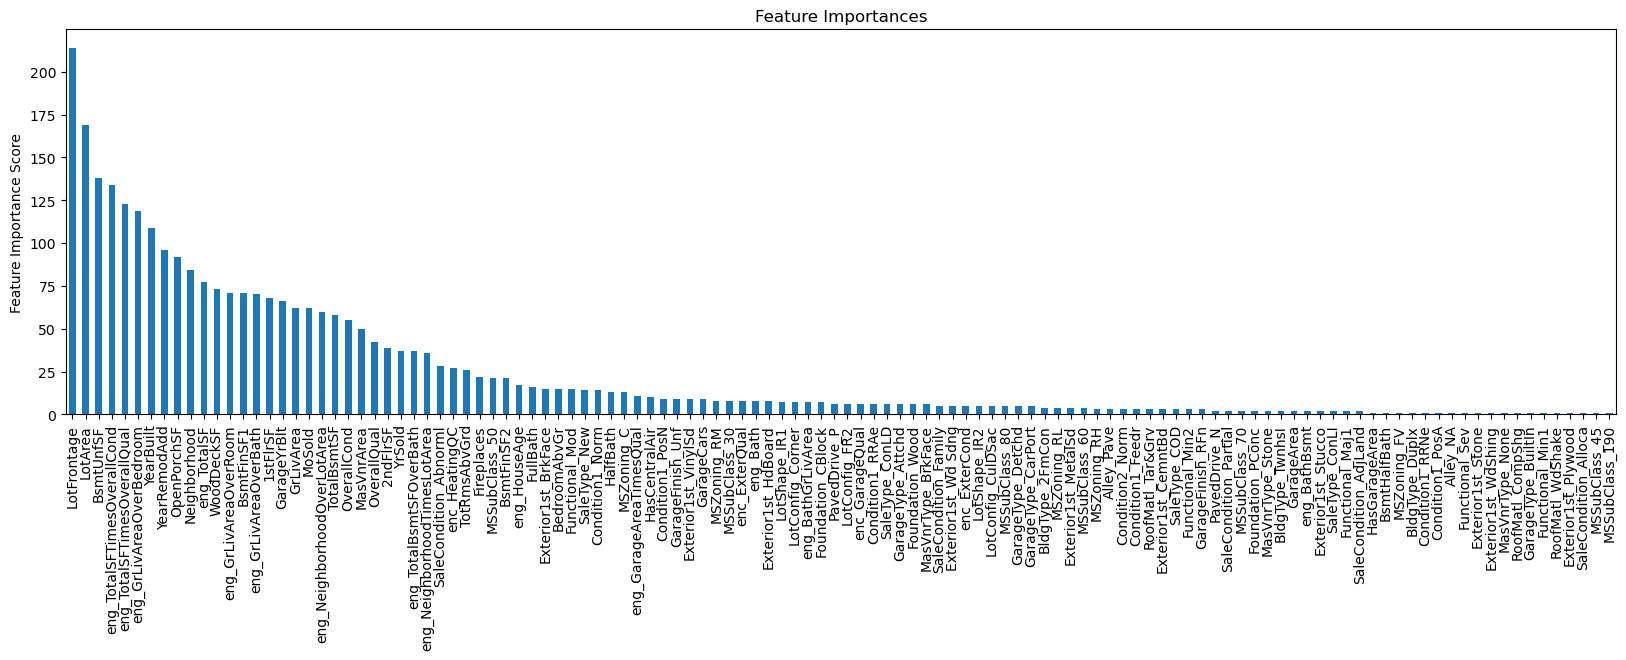

In [425]:
plt.figure(figsize=(20, 5))
plt.ylabel('Feature Importance Score')
best_result["feat_imp"].plot(kind='bar', title='Feature Importances')

## ElasticNet

In [320]:
def sample_params(rng):
    return {
        "alpha": rng.choice(np.logspace(-5, -2, 50)),
        "l1_ratio": rng.choice(rng.uniform(0.5, 1.0, 20)),
        "fit_intercept": True,
        "precompute": False,
        "max_iter": 20000,
        "copy_X": True,
        "tol": rng.choice(rng.uniform(0.001, 0.01, 10)),
        "warm_start": False,
        "positive": False,
        "random_state": RANDOM_STATE,
        "selection": "cyclic"
    }

# Best CV: 0.11735105578659175
# Best Params: {'alpha': np.float64(0.0009102981779915217), 'l1_ratio': np.float64(0.8403431627851062), 'fit_intercept': True, 
#               'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.002558022733184189), 
#               'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}





def run_elnet(rng, show_iter=False):
    best_score = 1
    for i in range(50):
        params = sample_params(rng)

        X, Y, Y_orig, X_test, Y_test = split_train_test_data()
        X, Y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, Y, Y_orig)

        cv = KFold(
              n_splits=5,
              shuffle=True,
              random_state=RANDOM_STATE
            )

        model = ElasticNet(**params)
        pipeline = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features, model=model)
        # Using cross_validate to get estimator data
        result = cross_validate(pipeline, X, Y, cv=cv, scoring="neg_root_mean_squared_error", error_score="raise", return_estimator=True)


        scores = result["test_score"] * -1
        print("scores:", scores)
        println()
        estimators = result["estimator"]
        if scores.mean() < best_score:
            best_score = scores.mean()
            best_params = params
            print("New Best", best_score, "Params:", best_params)

        if show_iter:
            iter = [it.named_steps["model"].n_iter_ for it in estimators if hasattr(it.named_steps["model"], "n_iter_")]
            print("Iterations:", iter)

    print("Best CV:", best_score)
    print("Best Params:", best_params)

run_elnet(np.random.default_rng(RANDOM_STATE))

scores: [0.13158323 0.11448601 0.11480549 0.13236087 0.11024541]
------------------------------
New Best 0.12069620336412876 Params: {'alpha': np.float64(0.003727593720314938), 'l1_ratio': np.float64(0.5167927876527322), 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.007169877860326253), 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}
scores: [0.12033223 0.1150682  0.11525697 0.13380076 0.11700596]
------------------------------
New Best 0.1202928233152474 Params: {'alpha': np.float64(0.00014563484775012445), 'l1_ratio': np.float64(0.8115935723430212), 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.002786617400583298), 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}
scores: [0.12154096 0.11266491 0.11155868 0.12897422 0.11250741]
------------------------------
New Best 0.11744923738726956 Params: {'alpha': np.float64

/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.204e+00, tolerance: 8.944e-01
  model = cd_fast.enet_coordinate_descent(


scores: [0.12376951 0.11785162 0.1179963  0.1363489  0.12388338]
------------------------------
scores: [0.12383947 0.11202845 0.1116609  0.12827601 0.11117315]
------------------------------
New Best 0.11739559669310881 Params: {'alpha': np.float64(0.0013894954943731374), 'l1_ratio': np.float64(0.5937538578638925), 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.007893254059649853), 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}
scores: [0.1364277  0.12082455 0.12062298 0.13821394 0.11479898]
------------------------------
scores: [0.12276457 0.11224037 0.11160042 0.12849081 0.11189199]
------------------------------
scores: [0.11975739 0.11475091 0.11448994 0.13334614 0.1156394 ]
------------------------------
scores: [0.12704721 0.11257889 0.11264697 0.1289862  0.10980681]
------------------------------
scores: [0.12269264 0.11670447 0.11716512 0.13578459 0.12189081]
------------------------------


/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.504e+00, tolerance: 1.386e+00
  model = cd_fast.enet_coordinate_descent(
/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.305e+00, tolerance: 1.438e+00
  model = cd_fast.enet_coordinate_descent(
/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

scores: [0.12462056 0.11844834 0.11827478 0.13660452 0.12472848]
------------------------------


...

/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.517e+00, tolerance: 7.418e-01
  model = cd_fast.enet_coordinate_descent(
/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.287e+00, tolerance: 7.697e-01
  model = cd_fast.enet_coordinate_descent(
/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

scores: [0.12494606 0.11862955 0.11830765 0.13681599 0.124876  ]
------------------------------
scores: [0.13543409 0.11953546 0.11949922 0.13725996 0.11378141]
------------------------------
scores: [0.11997527 0.11374734 0.11178703 0.13042486 0.11314404]
------------------------------
scores: [0.1233359  0.11754114 0.11789945 0.13616695 0.12341672]
------------------------------
scores: [0.13583571 0.11999551 0.11991149 0.13758964 0.11415078]
------------------------------
scores: [0.13555177 0.11965322 0.11960166 0.13733827 0.11386734]
------------------------------
scores: [0.11893306 0.11456047 0.11332353 0.13260627 0.11418921]
------------------------------
scores: [0.1238913  0.11204199 0.11170957 0.12822179 0.1111911 ]
------------------------------


/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.467e+00, tolerance: 1.126e+00
  model = cd_fast.enet_coordinate_descent(
/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.298e+00, tolerance: 1.168e+00
  model = cd_fast.enet_coordinate_descent(
/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

scores: [0.12478129 0.11853752 0.11829909 0.13670756 0.12478161]
------------------------------
Best CV: 0.11735105578659175
Best Params: {'alpha': np.float64(0.0009102981779915217), 'l1_ratio': np.float64(0.8403431627851062), 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': np.float64(0.002558022733184189), 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}


/Users/avrud/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.944e+00, tolerance: 1.173e+00
  model = cd_fast.enet_coordinate_descent(


## Lasso


In [158]:
def sample_params(rng):
    return {
        "alpha": 0.0007187203411199203,
        "fit_intercept": True,
        "precompute": False,
        "max_iter": 20000,
        "copy_X": True,
        "tol": 0.0038968245196834795,
        "warm_start": False,
        "positive": False,
        "random_state": RANDOM_STATE,
        "selection": "cyclic"
    }


def run_lasso(rng, show_iter=False):
    best_score = 1
    for i in range(30):
        params = sample_params(rng)

        X, Y, Y_orig, X_test, Y_test = split_train_test_data()
        X, Y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, Y, Y_orig)

        cv = KFold(
              n_splits=5,
              shuffle=True,
              random_state=RANDOM_STATE
            )

        model = Lasso(**params)
        pipeline = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features, model=model)
        # Using cross_validate to get estimator data
        result = cross_validate(pipeline, X, Y, cv=cv, scoring="neg_root_mean_squared_error", error_score="raise", return_estimator=True)

        scores = result["test_score"] * -1
        print("scores:", scores)
        println()
        estimators = result["estimator"]
        if scores.mean() < best_score:
            best_score = scores.mean()
            best_params = params
            print("New Best", best_score, "Params:", best_params)

        if show_iter:
            iter = [it.named_steps["model"].n_iter_ for it in estimators if hasattr(it.named_steps["model"], "n_iter_")]
            print("Iterations:", iter)

    print("Best CV:", best_score)
    print("Best Params:", best_params)

run_lasso(np.random.default_rng(RANDOM_STATE))

#############
# Best CV: 0.11737016644823724
# Best Params: {'alpha': np.float64(0.0007187203411199203), 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': 0.0038968245196834795, 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}
# Best 1: CV: 0.11742784047698533
# Best Params: {'alpha': np.float64(0.0009293062039294187), 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': 0.0038968245196834795, 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}

scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
New Best 0.11737016644823724 Params: {'alpha': 0.0007187203411199203, 'fit_intercept': True, 'precompute': False, 'max_iter': 20000, 'copy_X': True, 'tol': 0.0038968245196834795, 'warm_start': False, 'positive': False, 'random_state': 0, 'selection': 'cyclic'}
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
------------------------------
scores: [0.12253467 0.11214768 0.11168382 0.12826662 0.11221804]
--

## Stacking

In [298]:
X, Y, Y_orig, X_test, Y_test = split_train_test_data()
X, Y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, Y, Y_orig)

cv = KFold(
  n_splits=5,
  shuffle=True,
  random_state=RANDOM_STATE
)


rng = np.random.default_rng(RANDOM_STATE)

# LiRe: Linear Regression
# Lasso: Lasso
# ENet: ElasticNet
# Rig: Ridge
# XBReg: XGBRegressor
best_cv_mean = 999
best_std = 999
for i in range(20):
  final_model = Ridge(alpha=rng.choice(rng.uniform(0.8, 1.2, 20)))
  estimators = [
    #('Rig', get_model("Rig")),
    ('LiRe', get_model("LiRe")),
    ('ENet', get_model("ENet")),
    ('XGBReg', get_model("XBReg")),
  ]
  reg = StackingRegressor(
    estimators=estimators,
    #final_estimator=get_model("LiRe"),
    final_estimator=final_model,
  )
  pipeline = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features, model=reg)

  result = cross_val_score(pipeline, X, Y, cv=cv, scoring="neg_root_mean_squared_error", error_score="raise")
  cv_mean = np.mean(result) * -1
  if cv_mean < best_cv_mean:
    best_cv_mean = cv_mean
    best_std = np.std(result)
 
    printspace()
    print("New best alpha:", best_cv_mean)
    printspace()
 
printspace()
println()
print("Best CV Mean:", best_cv_mean, f"({best_cv})")
print("Params:", final_model.get_params()) 


###########
# Best 1: CV Mean: 0.11575093095099724 (999)
# Params: {'alpha': np.float64(0.5420550348240253), 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}


Model: Linear Regression
Parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Model: ElasticNet
Parameters: {'alpha': np.float64(0.0009102981779915217), 'copy_X': True, 'fit_intercept': True, 'l1_ratio': np.float64(0.8403431627851062), 'max_iter': 20000, 'positive': False, 'precompute': False, 'random_state': 0, 'selection': 'cyclic', 'tol': np.float64(0.002558022733184189), 'warm_start': False}
Model: XGBRegressor
Parameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.7320808520425763, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'rmse', 'feature_types': None, 'feature_weights': None, 'gamma': 0.012199053588004086, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_one

# Analysis

## Normalization and LogP1

Filling LotFrontage nulls with mean by Neighborhood
Filling LotFrontage nulls with mean by Neighborhood


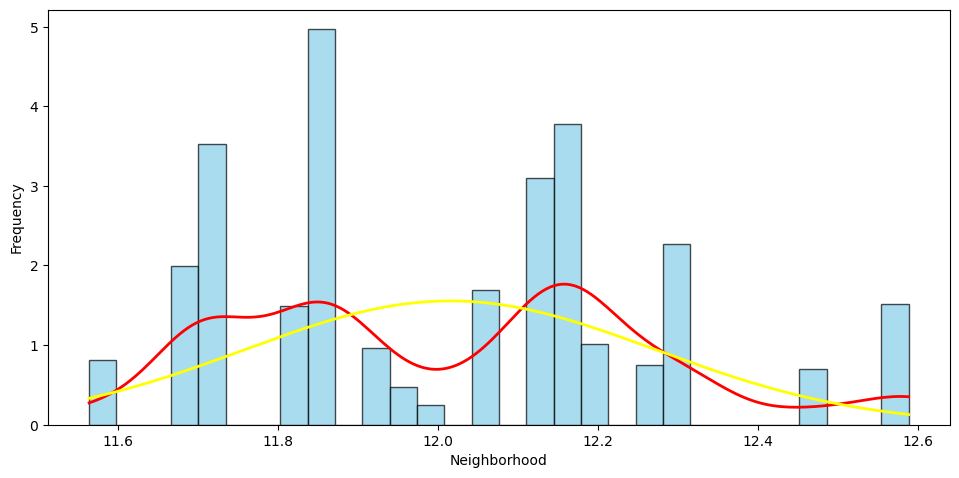

In [275]:
X, Y, Y_orig, X_test, Y_test = split_train_test_data()
X, Y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, Y, Y_orig)

dcols = ["Neighborhood", "eng_TotalSF", "eng_TotalSFTimesOverallQual", "eng_TotalSFTimesOverallCond", "eng_GarageAreaTimesQual", "eng_HouseAge",
            "eng_BathGrLivArea", "eng_BathBsmt", "eng_Bath", "eng_GrLivAreaOverRoom", "eng_GrLivAreaOverBedroom",
            "eng_GrLivAreaOverBath", "eng_TotalBsmtSFOverBath", "eng_GarageAreaOverCar", "eng_NeighborhoodOverLotArea", "eng_NeighborhoodTimesLotArea"]

dlcols = ["sqrt_TotalSF", "sqrt_TotalSFXOverallQual", "sqrt_TotalSFXOverallCond", "log1p_HouseAge", "sqrt_GrLivAreaOverRoom", "sqrt_GrLivAreaOverBath", "log1p_NeighborhoodTimesLotArea", "log1p_NeighborhoodOverLotArea"]

Xt = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features).fit(X, Y).transform(X)
Xt["sqrt_TotalSF"] = np.sqrt(Xt["eng_TotalSF"])
Xt["sqrt_TotalSFXOverallQual"] = np.sqrt(Xt["eng_TotalSFTimesOverallQual"])
Xt["sqrt_TotalSFXOverallCond"] = np.sqrt(Xt["eng_TotalSFTimesOverallCond"])

Xt["log1p_HouseAge"] = np.log1p(Xt["eng_HouseAge"])
Xt["sqrt_GrLivAreaOverRoom"] = np.sqrt(Xt["eng_GrLivAreaOverRoom"])
Xt["sqrt_GrLivAreaOverBath"] = np.sqrt(Xt["eng_GrLivAreaOverBath"])

Xt["log1p_NeighborhoodTimesLotArea"] = np.log1p(Xt["eng_NeighborhoodTimesLotArea"])
Xt["log1p_NeighborhoodOverLotArea"] = np.log1p(Xt["eng_NeighborhoodOverLotArea"])

eng_log1p_cols = "log1p_HouseAge", "log1p_NeighborhoodTimesLotArea", "log1p_NeighborhoodOverLotArea"
eng_sqrt_cols = ["sqrt_TotalSF", "sqrt_TotalSFXOverallQual", "sqrt_TotalSFXOverallCond", "sqrt_GrLivAreaOverRoom", "sqrt_GrLivAreaOverBath"]

show_distribution(Xt, ["Neighborhood"])
# show_distribution(Xt, dcols)
#show_distribution(Xt, dlcols)

# Observations
# - Applying log1p to TotalSF, TotalSFTimesOverallQual, sqrt_TotalSFXOverallCond, sqrt_GrLivAreaOverRoom:
#   ===> makes the distribution left skewed. Don't do. => Sqrt instead, makes the distribution closer to normal
# - House Age is right skewed and multimodal. Log1p works fine, but maybe trying creating two or three cats: old, med, new
# - s


## Residuals (Ridge)

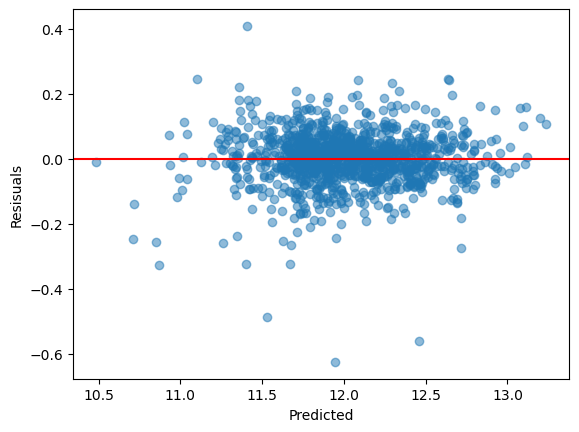

bin
(10.48, 11.73]      0.073239
(11.73, 11.896]     0.054386
(11.896, 12.09]     0.052457
(12.09, 12.335]     0.052323
(12.335, 13.238]    0.058619
Name: abs_res, dtype: float64


In [325]:
X, y, y_orig, X_test, y_test = split_train_test_data()
X, y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, y, y_orig)

def study_residuals(X, y):
  pip = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features, model=model)
  Xt = pip.fit(X, y).transform(X)

  rig = Ridge(alpha=0.7)
  preds = rig.fit(Xt, y).predict(Xt)
  residuals =  y - preds
  plt.scatter(preds, residuals, alpha=0.5)
  plt.axhline(0, color='red')
  plt.xlabel("Predicted")
  plt.ylabel("Resisuals")
  plt.show()


  df_res = pd.DataFrame({
    "y": y,
    "pred": preds,
    "residual": residuals
  })

  df_res["abs_res"] = np.abs(df_res["residual"])
  df_res["bin"] = pd.qcut(df_res["pred"], 5)
  return df_res

df_res = study_residuals(X, y)

print(df_res.groupby("bin")["abs_res"].mean())

In [320]:
bigres = df_res[df_res["residual"].abs() > 0.2].sort_values(by="residual", ascending=False)
bigres_idx = bigres.index

print("Mayor residuals shape:", bigres.shape)

df_base_data.iloc[bigres_idx].sort_values(by="YearBuilt", ascending=True)

# Observations
# All of this values corresponds to old houses.
# Let's remove this values and see what happen
# Train distribution for YearBuilt is similar than kaggle test data

Mayor residuals shape: (26, 5)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log1p
716,717,70,RM,60.0,10800,Pave,Grvl,Reg,Bnk,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2Story,7,8,1890,1998,Gable,CompShg,Wd Sdng,VinylSd,NaN,0.0,TA,Gd,BrkTil,TA,TA,No,Unf,0,Unf,0,718,718,GasA,Ex,Y,SBrkr,1576,978,0,2554,0,0,1,1,3,1,TA,8,Typ,0,NaN,Detchd,1996.0,Unf,2,704,TA,TA,P,0,48,143,0,0,0,NaN,NaN,NaN,0,7,2007,WD,Normal,159500,11.979805
88,89,50,C,105.0,8470,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,IDOTRR,Feedr,Feedr,1Fam,1.5Fin,3,2,1915,1982,Hip,CompShg,Plywood,Plywood,NaN,0.0,Fa,Fa,CBlock,TA,Fa,No,Unf,0,Unf,0,1013,1013,GasA,TA,N,SBrkr,1013,0,513,1526,0,0,1,0,2,1,Fa,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,0,156,0,0,0,NaN,MnPrv,NaN,0,10,2009,ConLD,Abnorml,85000,11.350418
495,496,30,C,60.0,7879,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,1Fam,1Story,4,5,1920,1950,Gable,CompShg,Wd Sdng,Wd Sdng,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,495,Unf,0,225,720,GasA,TA,N,FuseA,720,0,0,720,0,0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,N,0,523,115,0,0,0,NaN,GdWo,NaN,0,11,2009,WD,Abnorml,34900,10.460271
30,31,70,C,50.0,8500,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Feedr,Norm,1Fam,2Story,4,4,1920,1950,Gambrel,CompShg,BrkFace,BrkFace,NaN,0.0,TA,Fa,BrkTil,TA,TA,No,Unf,0,Unf,0,649,649,GasA,TA,N,SBrkr,649,668,0,1317,0,0,1,0,3,1,TA,6,Typ,0,NaN,Detchd,1920.0,Unf,1,250,TA,Fa,N,0,54,172,0,0,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal,40000,10.596660
1328,1329,50,RM,60.0,10440,Pave,Grvl,Reg,Lvl,AllPub,Corner,Gtl,OldTown,Norm,Norm,1Fam,1.5Fin,6,7,1920,1950,Gable,CompShg,BrkFace,Wd Sdng,NaN,0.0,Gd,Gd,BrkTil,Gd,TA,No,LwQ,493,Unf,0,1017,1510,GasW,Ex,Y,SBrkr,1584,1208,0,2792,0,0,2,0,5,1,TA,8,Mod,2,TA,Detchd,1920.0,Unf,2,520,Fa,TA,Y,0,547,0,0,480,0,NaN,MnPrv,Shed,1150,6,2008,WD,Normal,256000,12.452937
217,218,70,RM,57.0,9906,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2Story,4,4,1925,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0,Unf,0,686,686,GasA,Fa,N,SBrkr,810,518,0,1328,0,0,1,0,3,1,TA,8,Typ,0,NaN,Detchd,1940.0,Unf,1,210,TA,TA,Y,0,172,60,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Family,107000,11.580593
608,609,70,RL,78.0,12168,Pave,NaN,Reg,HLS,AllPub,Inside,Mod,Crawfor,Norm,Norm,1Fam,2Story,8,6,1934,1998,Gable,CompShg,BrkFace,Wd Sdng,NaN,0.0,TA,TA,PConc,Gd,TA,Mn,BLQ,428,Unf,0,537,965,GasA,TA,Y,SBrkr,1940,1254,0,3194,0,0,2,1,4,1,TA,10,Typ,2,Gd,Basment,1934.0,Unf,2,380,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,9,2007,WD,Alloca,359100,12.791359
1147,1148,70,RL,75.0,12000,Pave,NaN,Reg,Bnk,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,7,1941,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,275,Unf,0,429,704,GasA,Ex,Y,SBrkr,860,704,0,1564,0,0,1,1,3,1,Fa,7,Typ,1,Gd,Attchd,1941.0,Unf,1,234,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,7,2009,WD,Normal,174500,12.069686
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CemntBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500,12.493133
1427,1428,50,RL,60.0,10930,Pave,Grvl,Reg,Bnk,AllPub,Inside,Gtl,NAmes,Artery,No

Removed rows: 26 ( 2.2375 %)


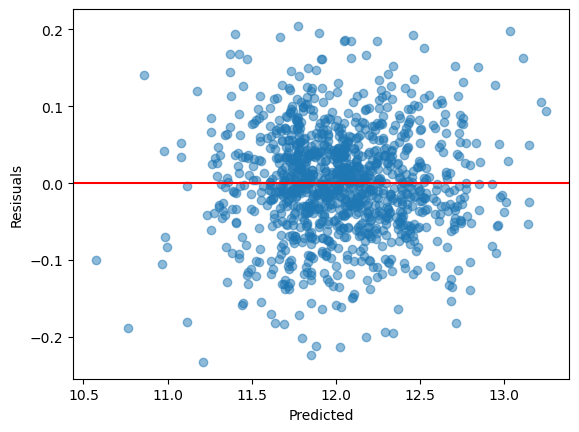

bin
(10.571, 11.738]    0.061198
(11.738, 11.905]    0.050018
(11.905, 12.092]    0.046844
(12.092, 12.333]    0.050022
(12.333, 13.252]    0.055764
Name: abs_res, dtype: float64
bin
(10.48, 11.73]      0.073239
(11.73, 11.896]     0.054386
(11.896, 12.09]     0.052457
(12.09, 12.335]     0.052323
(12.335, 13.238]    0.058619
Name: abs_res, dtype: float64


In [326]:
X, y, y_orig, X_test, y_test = split_train_test_data()
X, y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, y, y_orig)

# Removing residuals > 0.2 an see what happen.
nrows_b = X.shape[0]
X = X[~X.index.isin(bigres_idx)]
y = y[~y.index.isin(bigres_idx)]

print("Removed rows:", nrows_b - X.shape[0], "(", nfmt((nrows_b - X.shape[0]) / nrows_b * 100), "%)")

dfres_rem = study_residuals(X, y)


print(dfres_rem.groupby("bin")["abs_res"].mean())
print(df_res.groupby("bin")["abs_res"].mean())


In [323]:
#df_submit = pd.read_csv("./data/test.csv")

print(df_submit.shape)
df_submit[df_submit["YearBuilt"] < 2007].sort_values(by="YearBuilt", ascending=True).shape
df_submit["YearBuilt"].describe()

(1459, 80)


count    1459.000000
mean     1971.357779
std        30.390071
min      1879.000000
25%      1953.000000
50%      1973.000000
75%      2001.000000
max      2010.000000
Name: YearBuilt, dtype: float64

In [51]:
# ['1stFlrSF', 'Fireplaces', 'FullBath', 'GarageArea', 'GarageCars', 'GarageYrBlt', 'GrLivArea', 'OverallQual', 
# 'TotRmsAbvGrd', 'TotalBsmtSF', 'YearBuilt', 'YearRemodAdd', 'MSSubClass']

# Notes from EDA
# There are some outliers in 1stFlrSF, BuiltSF, GarageArea, GrLiveArea, TotalBsmtSF
# Fireplaces. 3 is not a common value. Test making it 2.
# What does fullbath == 0 means? Seems wrong value. Check.
# A lot of 0 in Fireplaces, FullBath, GarageArea, GarageCars, YearRemodAdd, TotalBsmtSF
# YearBuilt and YearRemodAdd are kind of noicy. 
# MSSubClass seems to have some signal. Check ANoVA. There are some very low values (out of trend) for some categories.
# Observations
# 1stFlrSF is heavy right skewed. Need to check outliers. Also it seems to have the same information than GrLivArea. Check removing or fixing the right skeew using log1p
# 2ndFlrSF is right skewed and it has a lot of 0. Suppose corresponds to houses not having 2nd floor. Maybe create a Has2ndFloor feature? Also check outliers.
# 3ssnPorch seems to be a constant  col. Check removal. If not, Has3SsnPorch?
# Same for EnclosedPorch
# GarageCars and GarageArea should provide the similar information. Try removing or using some combination. There are also several values = 0. Complement with field HasGarage 1/0
# There are a few samples having 3 bathrooms. Check if the related price. Consider creating a Has3Baths feature, or clipping value to 2.
# HalfBath mostly 0-1. Consider HasHalfBath
# Check 0 values in BedroomAbvGr
# BsmtFinSF1 has a lot of 0. Add HasBsmt 1/0. 
# BsmtFinSF2 Almost constant. Check
# BsmtHalfBath almost constant.
# Compare garage built with house built year. Check if has any signal.
# FullBath, a very few values > 2. Check signal. Consider adding HasFullBath
# KitchenAbvGr, a few values above 1. Almost constant, check signal.
# LotArea has 0 values? If yes, fix. Not possible data
# LowQualFinSF is almost constant. Check removal

def plot_grouped_mean(col):
  X, Y, Y_orig,  X_test, Y_test = split_train_test_data()
  df_eng =  X.copy().join(Y_orig)
  df_eng = df_eng.groupby(col).agg({
      #TARGET_COL: "mean",
      TARGET_COL: "count",
      #TARGET_COL: "mean",
  }).sort_values(by=TARGET_COL, ascending=False)
  #df_eng.plot(kind="bar")
  print(df_eng)

#plot_grouped_mean("Fireplaces")
#f_regression(X[["MSSubClass"]], Y, center=True)
#print_cardinal_info(X, Y, "3SsnPorch")


X, Y, Y_orig,  X_test, Y_test = split_train_test_data()
zero_cols = ["Fireplaces", "GarageArea", "GarageCars", "YearRemodAdd", "TotalBsmtSF", "2ndFlrSF", "EnclosedPorch", "BsmtFinSF2"]

cons_cols = ["3SsnPorch", "2ndFlrSF", "EnclosedPorch", "BsmtFinSF2"]
#for c in (zero_cols + cons_cols):
for c in ["HalfBath"]:
  #print_cardinal_info(X, Y, c)
  row_count = X.shape[0]
  unique_count = X[c].unique().shape[0]
  zero_count = X[X[c] == 0][c].shape[0]
  print(c, unique_count, "diff values")
  print(c, zero_count, "rows with 0 (", nfmt(zero_count / row_count * 100), "%)")
  new_col = f"Has{c}"
  X[new_col] = X[c].apply(lambda x: 0 if x == 0 else 1)
  print_cardinal_info(X, Y, new_col)
  printspace()

# Convert the fields in the column below in a list
# Fireplaces, FullBath, GarageArea, GarageCars, YearRemodAdd, TotalBsmtSF


X["HalfBath"].value_counts()

X.columns


NameError: name 'g_X' is not defined

# Residual analysis

# Stats

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

g_df_scores.loc[g_df_scores["failed"].isnull()] 
#show_global_scores()
#plot_scores()
#show_scores_stats()
#g_df_scores[g_df_scores["model"] == "XBReg"]
g_df_scores[["run_id", "model", "run_label", "CV_MEAN", "DESC"]].sort_values(by="CV_MEAN", ascending=True)
#g_df_scores[["run_id", "failed", "model", "run_label", "CV_MEAN", "DESC"]].sort_values(by="run_id", ascending=False)

# g_df_scores[g_df_scores["failed"] == False].groupby("run_id").agg({
#     "CV_MEAN": "mean",
#     "TRN_RMSE": "mean",
# }).sort_values(by="CV_MEAN", ascending=True)


# myscore = g_df_scores[g_df_scores["failed"] == False][["run_id", "model", "run_label", "CV_MEAN", "DESC", "date", "failed"]].sort_values(by="CV_MEAN", ascending=True)
# myscore[(myscore["run_id"] < 33) & (myscore["run_id"] > 9) & (myscore["model"] == "Rig")].head(30)
# pattern = r"col\s+'([^']+)'"

# Extracting column names from the DESC field ordered by score asc
# matches = myscore["DESC"].str.extractall(pattern)[0].unique().tolist()
# print(matches)
#show(g_df_scores)
#g_df_scores.
# c = ["Neighborhood", "MSZoning", "Functional", "CentralAir", "SaleCondition"]
# c1 = ["Condition2", "Street", "Exterior1st", "GarageType"]

#"BsmtFinSF2", "

#g_df_scores[g_df_scores["run_id"] > 135][["run_id", "model", "CV_MEAN", "validation_tag"]].sort_values(by="run_id", ascending=False)
g_df_scores.loc[g_df_scores["run_id"] == 139, "validation_tag"] = "cross_val_score"
# g_df_scores["validation_tag"]

# Removing Stats

In [ ]:
g_df_scores[g_df_scores["run_id"] > 96].sort_values(by="run_id", ascending=False)

# for i in range(98, 105):
#   mark_failed_score(i)
#mark_failed_score(82)

# Checks

In [ ]:
import re

def extract_bin_info_from_results(df):
  # Assuming your DataFrame is named df
  # Filter rows containing the target phrase
  df = df[df["failed"] == False]
  mask = df['DESC'].str.contains('Checking binary one by one', regex=False)
  filtered = df[mask]

  print("Found:", len(filtered))
  features = []
  mean_values = []
  models = []
  
  reg = re.compile("Checking binary one by one. Added (\\w+)")
  for row in filtered.iterrows():
    field_name = ""
    field_name = ""
    cv_mean = 0
    row = row[1]
    model = row['model']
    desc_text = row['DESC']
    # Extract field_name using regex
    #match = re.search(r'Added Has(\w+) from (\w+)', desc_text)
    #print(desc_text)
    matches = list(reg.finditer(desc_text))
    #print("m:", matches)
    #println()
    if len(matches) > 0:
      field_name = matches[-1].group(0).split()[-1]
      cv_mean = row['CV_MEAN']

    if field_name != "":
      #r = {"feature": field_name, "CV_MEAN": cv_mean}
      features.append(field_name)
      mean_values.append(cv_mean)
      models.append(model)
    #print("Field name:", field_name, "CV_MEAN", cv_mean)
  df_res = pd.DataFrame({
      "model": models,
      "feature": features,
      "CV_MEAN": mean_values
  })
  print(df_res.sort_values(by="CV_MEAN")["feature"]) 

extract_bin_info_from_results(g_df_scores)


In [ ]:
X, Y, Y_orig,  X_test, Y_test = split_train_test_data()

# show_distribution(pd.DataFrame(Y_test, columns=[LOGP_TARGET_COL]), features=[LOGP_TARGET_COL])
# show_distribution(pd.DataFrame(Y, columns=[LOGP_TARGET_COL]), features=[LOGP_TARGET_COL])
# df = pd.DataFrame({
#     "Y_test": Y_test,
#     "Y": Y
# })
# df.describe()

df = X_test.join(Y_test)

show_target_pairplot(df, ["GrLivArea", "GarageArea", "TotalBsmtSF", "1stFlrSF", "FullBath"], LOGP_TARGET_COL)


# Submission

In [ ]:
dft = df_raw_data.copy()
dfs = pd.read_csv("./data/test.csv")


# print(dft[dft.columns[(dft.isnull().sum() > 0).values]].isnull().sum())
# println()
# print(dfs[dfs.columns[(dfs.isnull().sum() > 0).values]].isnull().sum())
# println()
dfs = fix_nulls(dfs, X)
print(dfs[dfs.columns[(dfs.isnull().sum() > 0).values]].isnull().sum())
#dfs

## Functions

In [193]:
def train_data_for_submission():
  X = df_base_data.copy()
  y_orig = X.pop(TARGET_COL)
  y = np.log1p(y_orig)
  return X, y, y_orig

def save_submission(pd, folder="submissions", file_prefix="submission"):
    date_str = datetime.now().strftime("%y%m%d_%H%M")
    filename = f"./{folder}/{file_prefix}_{date_str}.csv"
    pred.to_csv(filename, index=False) 

## Process

In [143]:
def pip_steps_until(step_name="all", only_pip=True, return_names=False):
  pip = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features)
  if step == "all":
    return pip
  #pip.fit(X,y).transform(X)

  step_idx = [i for i, step in enumerate(pip.steps) if step[0] == step_name][0] + 1
  if only_pip:
    return pip[:step_idx]

  steps = pip.steps[:step_idx]
  if not return_names:
    return steps
  return [step[0] for step in steps]

In [122]:
list_models()



LiRe: Linear Regression
Lasso: Lasso
ENet: ElasticNet
Rig: Ridge
XBReg: XGBRegressor


In [235]:


dfs_an = pd.read_csv("./data/test.csv")
dfs_an = fix_nulls(dfs_an, X)
#dfs_an = fix_invalid(dfs_an)

dfs_an[dfs_an["GarageCars"] > 3][["GarageCars", "GarageArea", "GrLivArea"]]


# Garage Area is not correct for GarageCars > 3
#dfs_an[["GarageCars", "GarageArea", "GrLivArea"]].head(20)

dfs_an[dfs_an["GarageCars"] > 0][["GarageCars", "GarageArea"]]
#X[X["GarageArea"] != X["GarageCars"]][["GarageCars", "GarageArea"]].head(20)



,GarageCars,GarageArea
0,1.0,730.0
1,1.0,312.0
2,2.0,482.0
3,2.0,470.0
4,2.0,506.0
5,2.0,440.0
6,2.0,420.0
7,2.0,393.0
8,2.0,506.0
9,2.0,525.0


In [377]:
#X, y, y_orig, _, _ = split_train_test_data()
X, y, y_orig = train_data_for_submission()


X, y, _, ignored_cols, ord_cols_used, desc = initial_processing(X, y, y_orig)

X = X[~X.index.isin(bigres_idx)]
y = y[~y.index.isin(bigres_idx)]

df_submit = pd.read_csv("./data/test.csv")
# df_submit = fix_nulls(df_submit, X)
# df_submit = fix_invalid(df_submit)

# Removing this rows improves score a little bit (as in CV)
df_submit.loc[df_submit["GrLivArea"] > 4000, ["GrLivArea"]] = 3999

estimators = [
    #('Rig', get_model("Rig")),
    ('LiRe', get_model("LiRe")),
    ('ENet', get_model("ENet")),
    ('XGBReg', get_model("XBReg")),
]
model = StackingRegressor(
    estimators=estimators,
    #final_estimator=get_model("LiRe"),
    final_estimator=get_model("Rig"),
)
#model = get_model("ENet")
println()
pip = create_pipeline(bin_cols, bin_cols_spec, ignored_cols, ord_cols_used, log1p_cols, norm_cols, create_eng_features, model=model).fit(X, y)

submit_id = df_submit.pop("Id")
pred = pd.Series(pip.predict(df_submit))


print("id", type(submit_id))
print("pri", type(pred))
pred = pd.concat({"Id": submit_id, "SalePrice": np.expm1(pred)}, axis=1)  # Inverse log1p transformation

save_submission(pred)
pred.head()


Model: Linear Regression
Parameters: {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}
Model: ElasticNet
Parameters: {'alpha': np.float64(0.0009102981779915217), 'copy_X': True, 'fit_intercept': True, 'l1_ratio': np.float64(0.8403431627851062), 'max_iter': 20000, 'positive': False, 'precompute': False, 'random_state': 0, 'selection': 'cyclic', 'tol': np.float64(0.002558022733184189), 'warm_start': False}
Model: XGBRegressor
Parameters: {'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.7320808520425763, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'rmse', 'feature_types': None, 'feature_weights': None, 'gamma': 0.012199053588004086, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_one

,Id,SalePrice
0,1461,119503.948032
1,1462,162578.233317
2,1463,184932.346606
3,1464,196692.885007
4,1465,181413.502354


In [200]:
# Comparing with previous submission.
dfs = pd.read_csv("./submissions/submission_260406.csv")
dfs = pd.read_csv("./submissions/submission_260406_1542.csv").join(dfs, lsuffix="_bef", rsuffix="_aft").drop(columns=["Id_aft"], errors="ignore").rename(columns={"Id_bef": "Id"})
dfs["delta"] = dfs["SalePrice_aft"] - dfs["SalePrice_bef"]

print("Submission Delta mean:", dfs["delta"].mean())
print("Submission Delta median:", dfs["delta"].median())


#dfs.head()
dfs[dfs["Id"] == 2550]


Submission Delta mean: 53.89746713231075
Submission Delta median: 11.721274496245314


,Id,SalePrice_bef,SalePrice_aft,delta
1089,2550,868567.691829,870616.91083,2049.219001
